In [1508]:
import pandas as pd
print("python is working")

python is working


In [1509]:
import pandas as pd

df = pd.read_csv("../data/ChargingRecords.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (72856, 13)


,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,EndDatetime,Duration,Demand
0,0,1,1,hotel,0,2022-09-15,20:54:02,2022-09-15,23:59:13,2022-09-15 20:54,2022-09-15 23:59,185,20.36
1,0,1,1,hotel,0,2022-09-14,20:01:05,2022-09-14,21:31:04,2022-09-14 20:01,2022-09-14 21:31,90,10.19
2,0,1,1,hotel,0,2022-09-14,18:54:30,2022-09-14,19:54:29,2022-09-14 18:54,2022-09-14 19:54,60,6.78
3,0,1,1,hotel,0,2022-09-29,18:32:51,2022-09-30,0:16:42,2022-09-29 18:32,2022-09-30 0:16,344,37.65
4,0,1,1,hotel,0,2022-09-25,19:30:15,2022-09-26,0:30:14,2022-09-25 19:30,2022-09-26 0:30,300,33.81


In [1510]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (72856, 13)

Column Names:
['UserID', 'ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime', 'EndDatetime', 'Duration', 'Demand']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 72856 entries, 0 to 72855
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UserID          72856 non-null  int64  
 1   ChargerID       72856 non-null  int64  
 2   ChargerCompany  72856 non-null  int64  
 3   Location        72856 non-null  str    
 4   ChargerType     72856 non-null  int64  
 5   StartDay        72856 non-null  str    
 6   StartTime       72856 non-null  str    
 7   EndDay          72856 non-null  str    
 8   EndTime         72856 non-null  str    
 9   StartDatetime   72856 non-null  str    
 10  EndDatetime     72856 non-null  str    
 11  Duration        72856 non-null  int64  
 12  Demand          72856 non-null  fl

In [1511]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Check unique values
print("\nUnique Values:")
print(df.nunique())

Missing Values:
UserID            0
ChargerID         0
ChargerCompany    0
Location          0
ChargerType       0
StartDay          0
StartTime         0
EndDay            0
EndTime           0
StartDatetime     0
EndDatetime       0
Duration          0
Demand            0
dtype: int64

Duplicate Rows: 13

Unique Values:
UserID             2337
ChargerID          2119
ChargerCompany        2
Location             14
ChargerType           2
StartDay            366
StartTime         43245
EndDay              365
EndTime           46710
StartDatetime     65628
EndDatetime       66745
Duration            979
Demand             6046
dtype: int64


In [1512]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("New dataset shape:", df.shape)

Duplicates removed successfully!
New dataset shape: (72843, 13)


In [1513]:
print("Data Types:")
print(df.dtypes)

Data Types:
UserID              int64
ChargerID           int64
ChargerCompany      int64
Location              str
ChargerType         int64
StartDay              str
StartTime             str
EndDay                str
EndTime               str
StartDatetime         str
EndDatetime           str
Duration            int64
Demand            float64
dtype: object


In [1514]:
# Convert date/time columns to datetime format

df["StartDatetime"] = pd.to_datetime(df["StartDatetime"])
df["EndDatetime"] = pd.to_datetime(df["EndDatetime"])

print("DateTime conversion completed successfully!")
print(df[["StartDatetime", "EndDatetime"]].dtypes)

DateTime conversion completed successfully!
StartDatetime    datetime64[us]
EndDatetime      datetime64[us]
dtype: object


In [1515]:
# Create time-based features

df["StartHour"] = df["StartDatetime"].dt.hour
df["StartDayOfWeek"] = df["StartDatetime"].dt.day_name()
df["StartMonth"] = df["StartDatetime"].dt.month

print("Time-based features created successfully!")
print(df[["StartDatetime", "StartHour", "StartDayOfWeek", "StartMonth"]].head())

Time-based features created successfully!
        StartDatetime  StartHour StartDayOfWeek  StartMonth
0 2022-09-15 20:54:00         20       Thursday           9
1 2022-09-14 20:01:00         20      Wednesday           9
2 2022-09-14 18:54:00         18      Wednesday           9
3 2022-09-29 18:32:00         18       Thursday           9
4 2022-09-25 19:30:00         19         Sunday           9


In [1516]:
# Basic statistical summary of Demand

print("Demand Statistics:")
print(df["Demand"].describe())

Demand Statistics:
count    72843.000000
mean        17.442667
std         13.491446
min          0.010000
25%          7.530000
50%         14.100000
75%         23.200000
max         97.000000
Name: Demand, dtype: float64


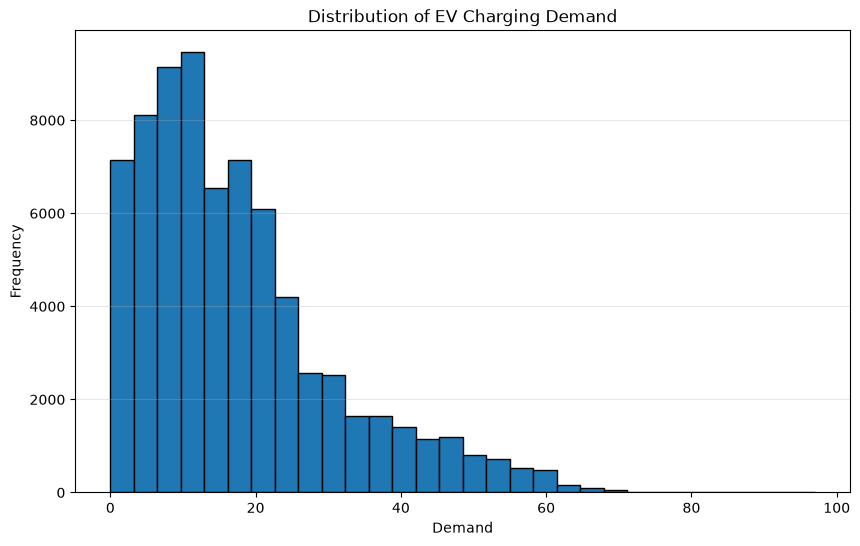

In [1517]:
# Distribution of EV Charging Demand

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["Demand"], bins=30, edgecolor="black")

plt.title("Distribution of EV Charging Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.show()

In [1518]:
# Average charging demand by hour

hourly_demand = df.groupby("StartHour")["Demand"].mean()

print("Average Demand by Hour:")
print(hourly_demand)

Average Demand by Hour:
StartHour
0     26.547193
1     25.319131
2     25.036850
3     20.249701
4     18.259526
5     17.245738
6     16.985157
7     16.810864
8     17.517359
9     14.408479
10    13.420777
11    13.718823
12    13.417219
13    13.705993
14    14.096955
15    14.061471
16    15.553976
17    16.994120
18    18.343036
19    20.001312
20    21.548303
21    22.847293
22    23.797213
23    27.713834
Name: Demand, dtype: float64


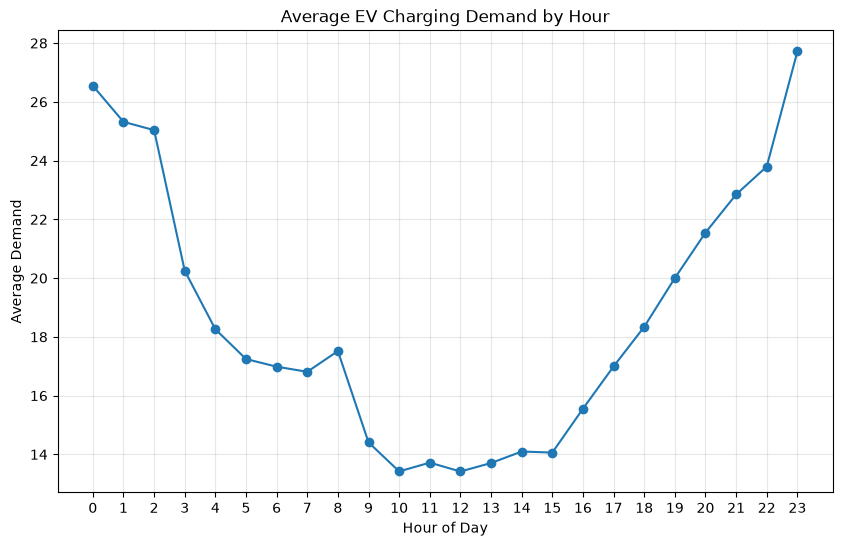

In [1519]:
# Average EV charging demand by hour

plt.figure(figsize=(10, 6))

plt.plot(hourly_demand.index, hourly_demand.values, marker="o")

plt.title("Average EV Charging Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

In [1520]:
# Average charging demand by day of week

daily_demand = df.groupby("StartDayOfWeek")["Demand"].mean()

print("Average Demand by Day:")
print(daily_demand)

Average Demand by Day:
StartDayOfWeek
Friday       17.306846
Monday       17.352955
Saturday     17.420183
Sunday       17.805558
Thursday     17.630799
Tuesday      17.101793
Wednesday    17.528346
Name: Demand, dtype: float64


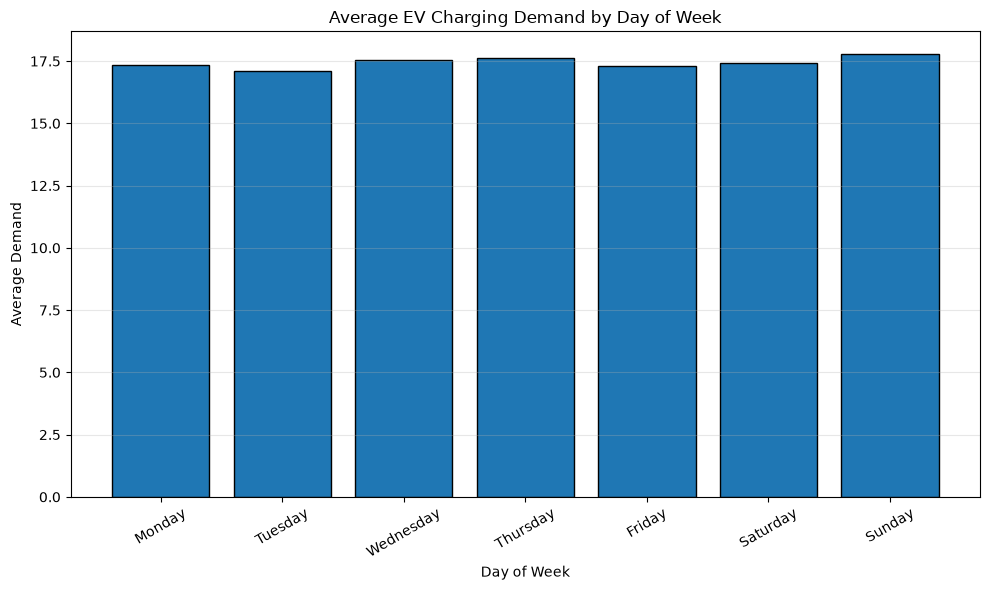

In [1521]:
# Visualize average charging demand by day of week

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_demand = daily_demand.reindex(day_order)

plt.figure(figsize=(10, 6))

plt.bar(daily_demand.index, daily_demand.values, edgecolor="black")

plt.title("Average EV Charging Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1522]:
# Average charging demand by charger company

company_demand = df.groupby("ChargerCompany")["Demand"].mean()

print("Average Demand by Charger Company:")
print(company_demand)

Average Demand by Charger Company:
ChargerCompany
0    16.695529
1    17.886187
Name: Demand, dtype: float64


In [1523]:
# Number of charging sessions by charger company

company_sessions = df["ChargerCompany"].value_counts().sort_index()

print("Number of Charging Sessions by Company:")
print(company_sessions)

Number of Charging Sessions by Company:
ChargerCompany
0    27134
1    45709
Name: count, dtype: int64


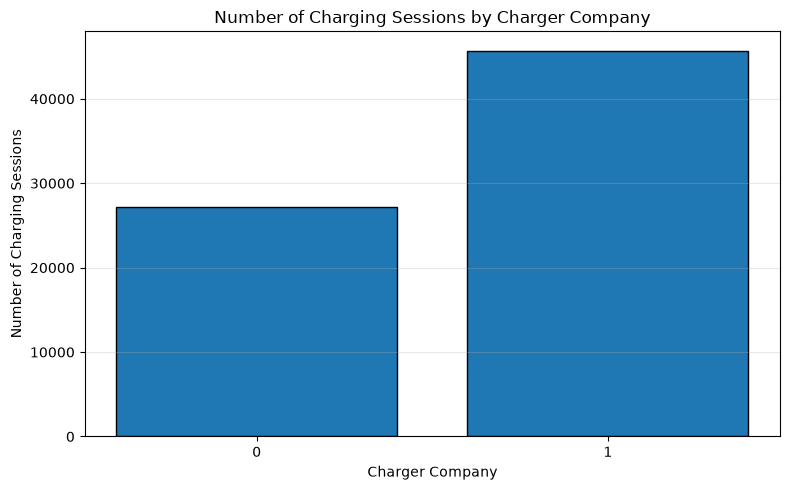

In [1524]:
# Visualize charging sessions by charger company

plt.figure(figsize=(8, 5))

plt.bar(
    company_sessions.index.astype(str),
    company_sessions.values,
    edgecolor="black"
)

plt.title("Number of Charging Sessions by Charger Company")
plt.xlabel("Charger Company")
plt.ylabel("Number of Charging Sessions")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1525]:
# Average charging demand by location

location_demand = df.groupby("Location")["Demand"].mean().sort_values(ascending=False)

print("Average Demand by Location:")
print(location_demand)

Average Demand by Location:
Location
accommodation         29.055829
bus garage            28.587586
camping               25.525288
apartment             18.744879
public area           17.899891
restaurant            17.813123
public institution    17.399318
resort                17.280838
public parking lot    17.187510
golf                  16.718299
market                16.567338
company               16.248039
sightseeing           15.245129
hotel                 14.702966
Name: Demand, dtype: float64


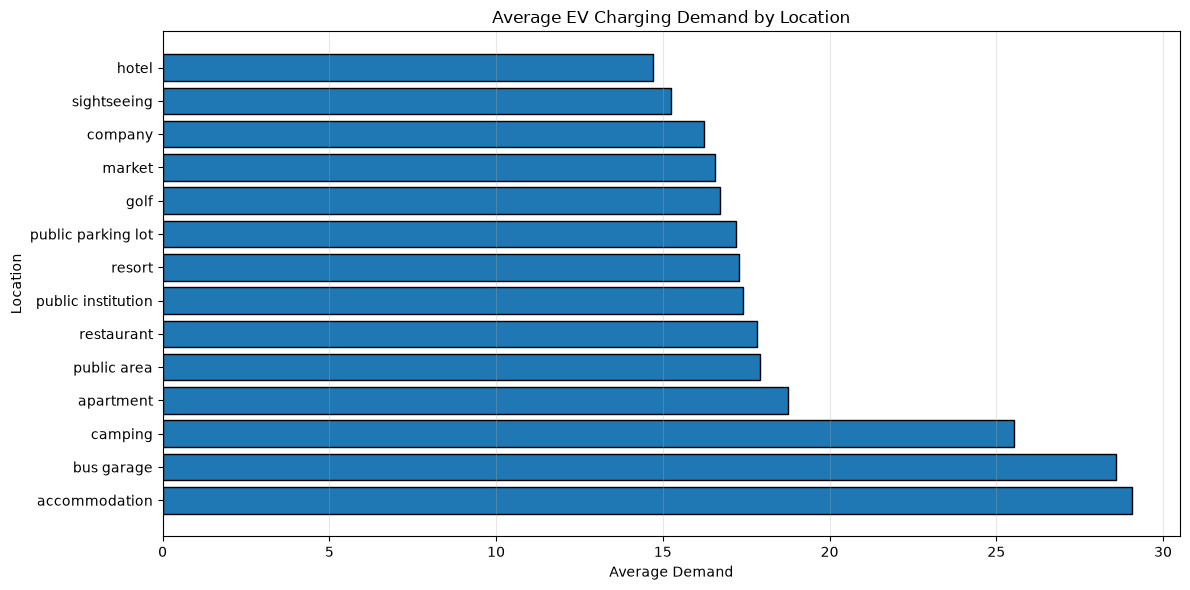

In [1526]:
# Visualize average charging demand by location

plt.figure(figsize=(12, 6))

plt.barh(
    location_demand.index,
    location_demand.values,
    edgecolor="black"
)

plt.title("Average EV Charging Demand by Location")
plt.xlabel("Average Demand")
plt.ylabel("Location")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [1527]:
# Average charging demand by charger type

charger_type_demand = (
    df.groupby("ChargerType")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Demand by Charger Type:")
print(charger_type_demand)

Average Demand by Charger Type:
ChargerType
1    18.955904
0    17.051995
Name: Demand, dtype: float64


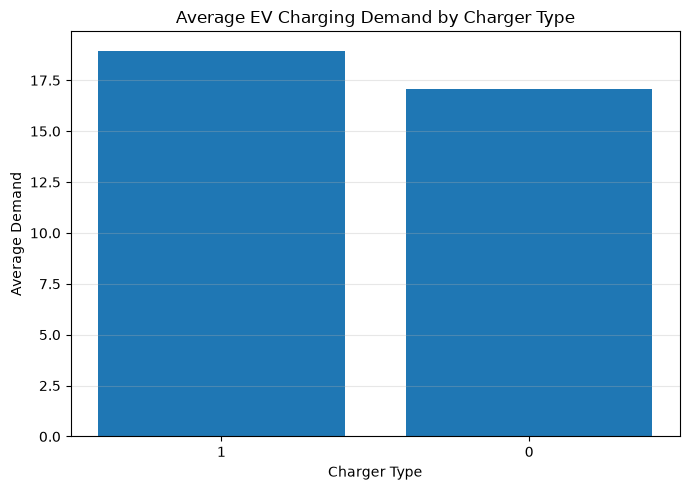

In [1528]:
# Visualize average charging demand by charger type

plt.figure(figsize=(7,5))

plt.bar(
    charger_type_demand.index.astype(str),
    charger_type_demand.values
)

plt.title("Average EV Charging Demand by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Average Demand")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1529]:
# Correlation analysis of numerical features

numeric_cols = [
    "ChargerType",
    "Duration",
    "Demand",
    "StartHour",
    "StartMonth"
]

correlation = df[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
             ChargerType  Duration    Demand  StartHour  StartMonth
ChargerType     1.000000 -0.399730  0.056991  -0.066379   -0.032977
Duration       -0.399730  1.000000  0.656373   0.154166    0.016942
Demand          0.056991  0.656373  1.000000   0.126578   -0.005098
StartHour      -0.066379  0.154166  0.126578   1.000000   -0.001307
StartMonth     -0.032977  0.016942 -0.005098  -0.001307    1.000000


In [1530]:
import seaborn as sns

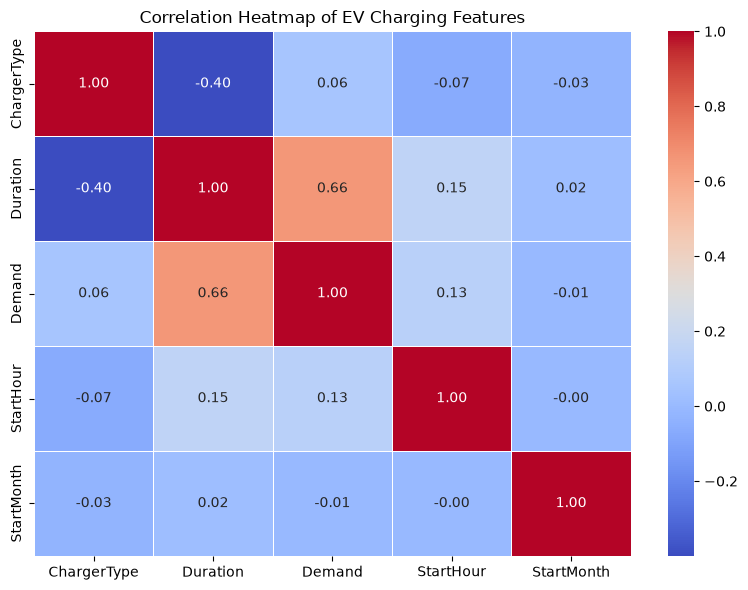

In [1531]:
# Visualize correlation using heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of EV Charging Features")
plt.tight_layout()
plt.show()

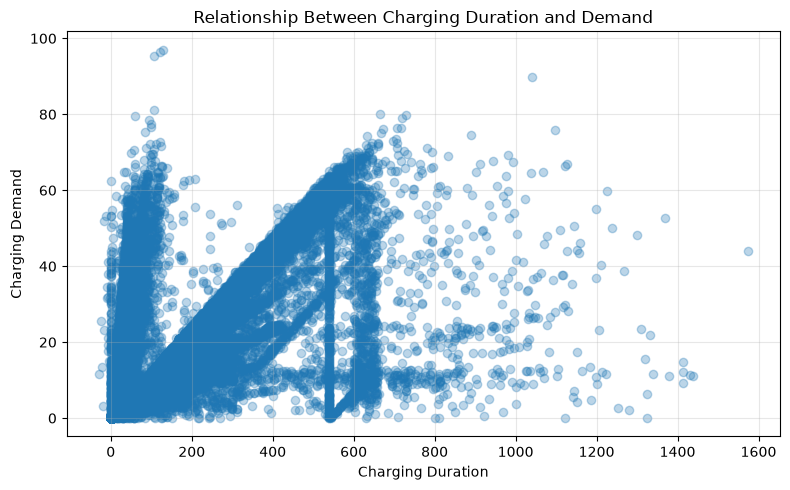

In [1532]:
# Relationship between charging duration and demand

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Duration"],
    df["Demand"],
    alpha=0.3
)

plt.title("Relationship Between Charging Duration and Demand")
plt.xlabel("Charging Duration")
plt.ylabel("Charging Demand")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

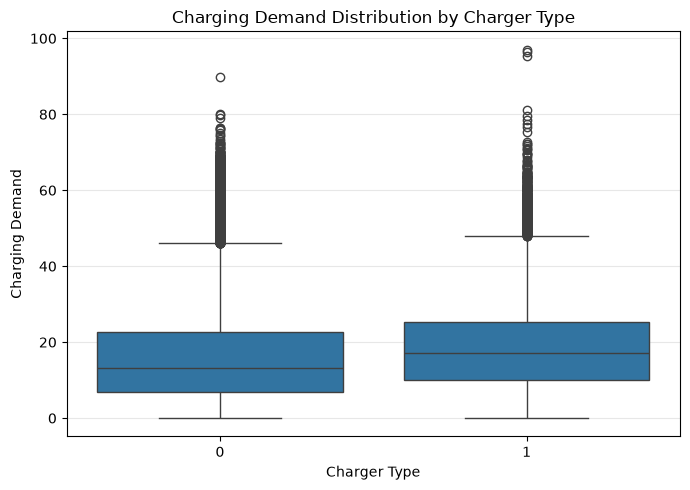

In [1533]:
# Compare demand across charger types

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="ChargerType",
    y="Demand",
    data=df
)

plt.title("Charging Demand Distribution by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Charging Demand")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1534]:
# Average charging demand by day and hour

day_hour_demand = pd.pivot_table(
    df,
    values="Demand",
    index="StartDayOfWeek",
    columns="StartHour",
    aggfunc="mean"
)

print("Average Demand by Day and Hour:")
print(day_hour_demand)

Average Demand by Day and Hour:
StartHour              0          1          2          3          4   \
StartDayOfWeek                                                          
Friday          27.534891  23.770968  26.899667  21.621905  16.137273   
Monday          25.535641  26.272414  24.763810  18.972000  15.035600   
Saturday        26.971973  22.701667  22.811944  19.480870  18.100833   
Sunday          25.898741  27.600132  29.291613  17.792632  21.424074   
Thursday        26.752558  24.789706  22.147143  20.106154  20.323571   
Tuesday         26.744508  27.045581  22.814333  20.270714  19.964000   
Wednesday       26.225758  25.838906  25.856452  23.884375  16.302222   

StartHour              5          6          7          8          9   ...  \
StartDayOfWeek                                                         ...   
Friday          19.624624  16.618571  16.609058  18.031280  14.156114  ...   
Monday          16.474568  17.685618  16.641784  17.354173  15.178641  ...  

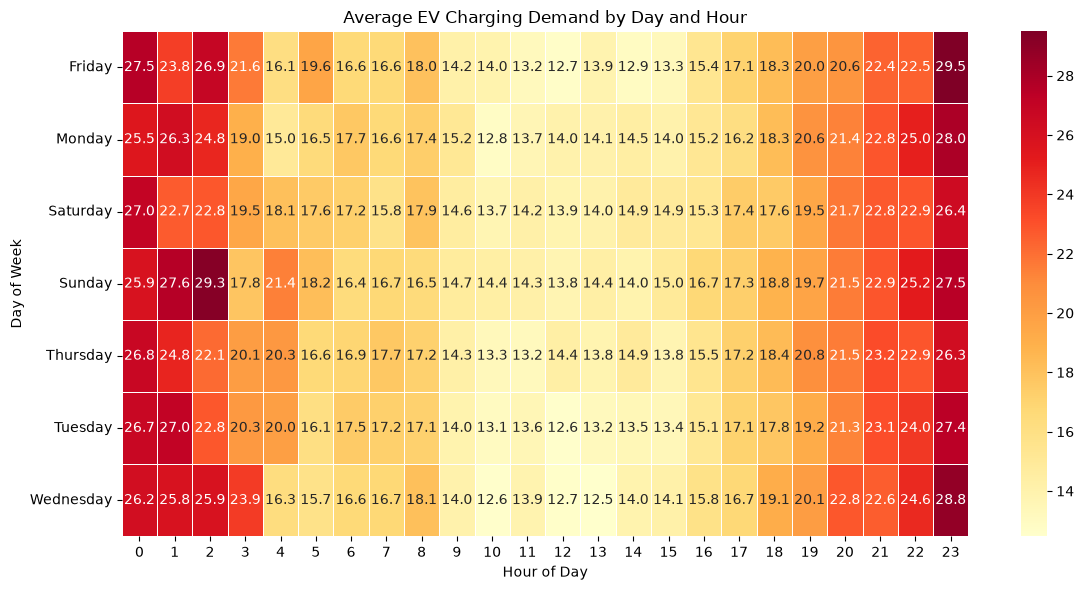

In [1535]:
# Visualize average demand by day and hour

plt.figure(figsize=(12, 6))

sns.heatmap(
    day_hour_demand,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Average EV Charging Demand by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [1536]:
# Average charging demand by month

monthly_demand = (
    df.groupby("StartMonth")["Demand"]
    .mean()
    .sort_index()
)

print("Average Demand by Month:")
print(monthly_demand)

Average Demand by Month:
StartMonth
1     17.391593
2     17.674622
3     17.485474
4     17.384997
5     17.239948
6     17.471306
7     17.708754
8     17.696557
9     17.792391
10    16.522514
11    16.758129
12    17.529455
Name: Demand, dtype: float64


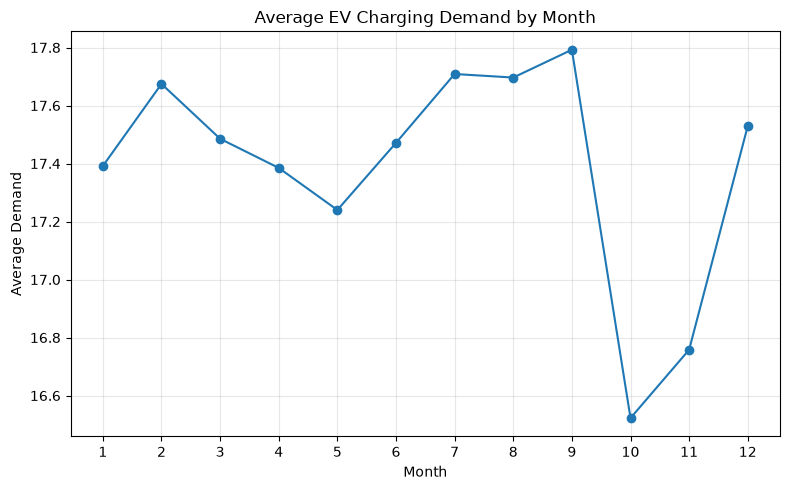

In [1537]:
# Visualize average charging demand by month

plt.figure(figsize=(8, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Average EV Charging Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [1538]:
# Basic statistical summary of charging duration

print("Charging Duration Statistics:")
print(df["Duration"].describe())

Charging Duration Statistics:
count    72843.000000
mean       151.183998
std        146.420312
min        -29.000000
25%         40.000000
50%        112.000000
75%        202.000000
max       1573.000000
Name: Duration, dtype: float64


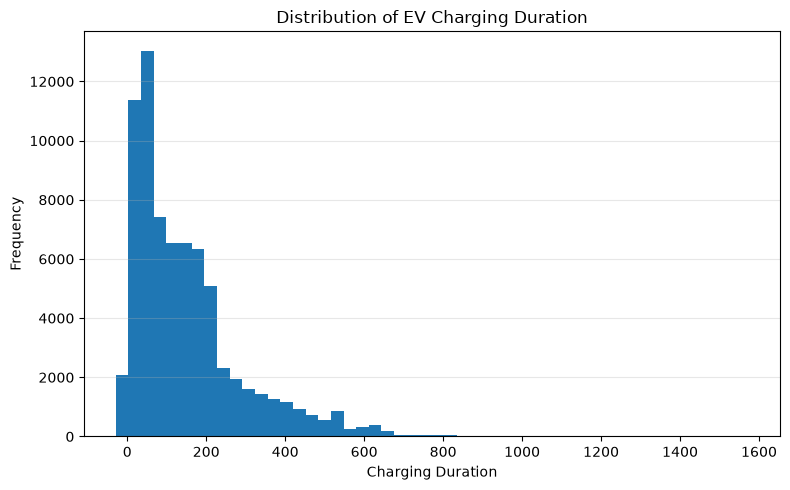

In [1539]:
# Distribution of charging duration

plt.figure(figsize=(8, 5))

plt.hist(df["Duration"], bins=50)

plt.title("Distribution of EV Charging Duration")
plt.xlabel("Charging Duration")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1540]:
# Check invalid charging duration values

negative_duration = (df["Duration"] < 0).sum()

print("Number of negative duration values:", negative_duration)

print("\nNegative duration records:")
print(df[df["Duration"] < 0][["Duration"]].head())

Number of negative duration values: 17

Negative duration records:
       Duration
55422       -29
55425        -9
55427        -8
55455        -6
55457       -21


In [1541]:
# Remove invalid negative charging duration values

df_clean = df[df["Duration"] >= 0].copy()

print("Original number of records:", len(df))
print("Cleaned number of records:", len(df_clean))
print("Removed invalid records:", len(df) - len(df_clean))

Original number of records: 72843
Cleaned number of records: 72826
Removed invalid records: 17


In [1542]:
# Detect outliers in charging duration using IQR method

Q1 = df_clean["Duration"].quantile(0.25)
Q3 = df_clean["Duration"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["Duration"] < lower_bound) |
    (df_clean["Duration"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Duration Outliers:", len(outliers))

Q1: 40.0
Q3: 202.0
IQR: 162.0
Lower Bound: -203.0
Upper Bound: 445.0
Number of Duration Outliers: 3922


In [1543]:
# Inspect duration outliers

print("Number of outliers:", len(outliers))

print("\nOutlier Duration Statistics:")
print(outliers["Duration"].describe())

print("\nFirst 10 Outlier Records:")
print(outliers[["Duration", "Demand", "ChargerType", "StartHour"]].head(10))

Number of outliers: 3922

Outlier Duration Statistics:
count    3922.000000
mean      575.605048
std       135.925941
min       446.000000
25%       489.000000
50%       540.000000
75%       616.000000
max      1573.000000
Name: Duration, dtype: float64

First 10 Outlier Records:
     Duration  Demand  ChargerType  StartHour
7         494   55.17            0         19
12        493   55.83            0         19
49        540   61.67            0         20
92        540   61.64            0         20
100       531   41.33            0         21
102       460   51.70            0         20
128       487   52.58            0         19
146       540   15.47            0         17
193       515   58.54            0         22
201       540    6.31            0          9


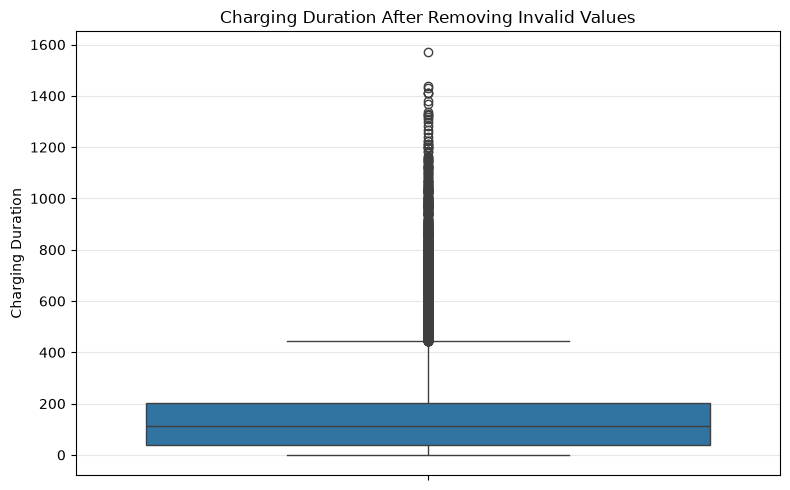

In [1544]:
# Boxplot of charging duration after removing invalid negative values

plt.figure(figsize=(8, 5))

sns.boxplot(y=df_clean["Duration"])

plt.title("Charging Duration After Removing Invalid Values")
plt.ylabel("Charging Duration")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1545]:
# Remove extreme duration outliers using IQR method

df_final = df_clean[
    (df_clean["Duration"] >= lower_bound) &
    (df_clean["Duration"] <= upper_bound)
].copy()

print("Original cleaned records:", len(df_clean))
print("Final records after outlier removal:", len(df_final))
print("Removed outlier records:", len(df_clean) - len(df_final))

Original cleaned records: 72826
Final records after outlier removal: 68904
Removed outlier records: 3922


In [1546]:
# Final dataset verification

print("Final Dataset Shape:", df_final.shape)

print("\nMissing Values:")
print(df_final.isnull().sum())

print("\nNegative Duration Values:",
      (df_final["Duration"] < 0).sum())

print("\nFinal Duration Range:")
print("Minimum:", df_final["Duration"].min())
print("Maximum:", df_final["Duration"].max())

Final Dataset Shape: (68904, 16)

Missing Values:
UserID            0
ChargerID         0
ChargerCompany    0
Location          0
ChargerType       0
StartDay          0
StartTime         0
EndDay            0
EndTime           0
StartDatetime     0
EndDatetime       0
Duration          0
Demand            0
StartHour         0
StartDayOfWeek    0
StartMonth        0
dtype: int64

Negative Duration Values: 0

Final Duration Range:
Minimum: 0
Maximum: 445


In [1547]:
# Basic statistical summary of charging demand

print("Charging Demand Statistics:")
print(df_final["Demand"].describe())

Charging Demand Statistics:
count    68904.000000
mean        16.077501
std         11.679474
min          0.010000
25%          7.250000
50%         13.520000
75%         22.300000
max         97.000000
Name: Demand, dtype: float64


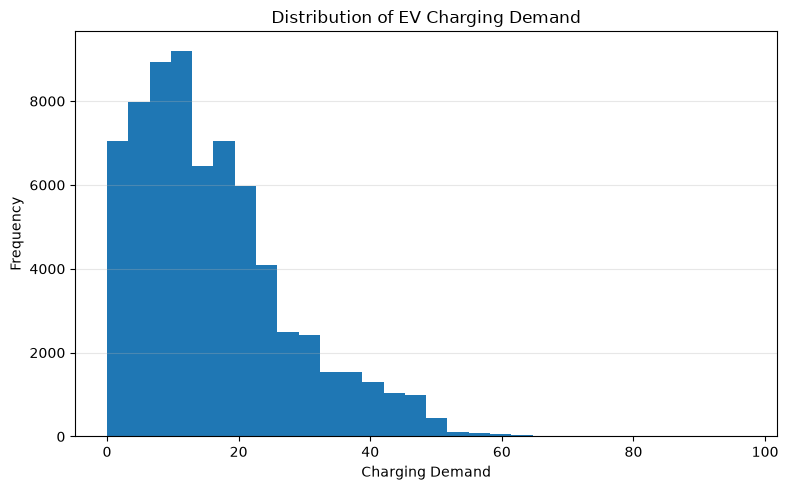

In [1548]:
# Distribution of charging demand

plt.figure(figsize=(8, 5))

plt.hist(df_final["Demand"], bins=30)

plt.title("Distribution of EV Charging Demand")
plt.xlabel("Charging Demand")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1549]:
# Average charging demand by charger type

charger_type_demand_final = (
    df_final.groupby("ChargerType")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Demand by Charger Type:")
print(charger_type_demand_final)

Average Demand by Charger Type:
ChargerType
1    18.946075
0    15.284283
Name: Demand, dtype: float64


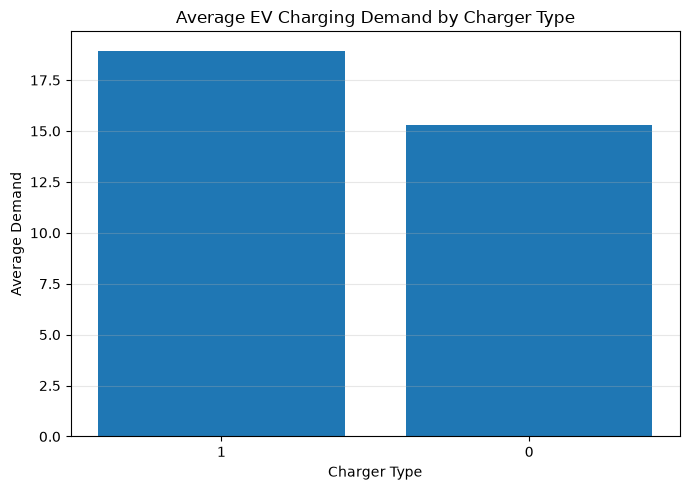

In [1550]:
# Average EV charging demand by charger type

plt.figure(figsize=(7, 5))

plt.bar(
    charger_type_demand_final.index.astype(str),
    charger_type_demand_final.values
)

plt.title("Average EV Charging Demand by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Average Demand")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1551]:
# Average charging duration by charger type

charger_type_duration = (
    df_final.groupby("ChargerType")["Duration"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Charging Duration by Charger Type:")
print(charger_type_duration)

Average Charging Duration by Charger Type:
ChargerType
0    152.301178
1     35.807651
Name: Duration, dtype: float64


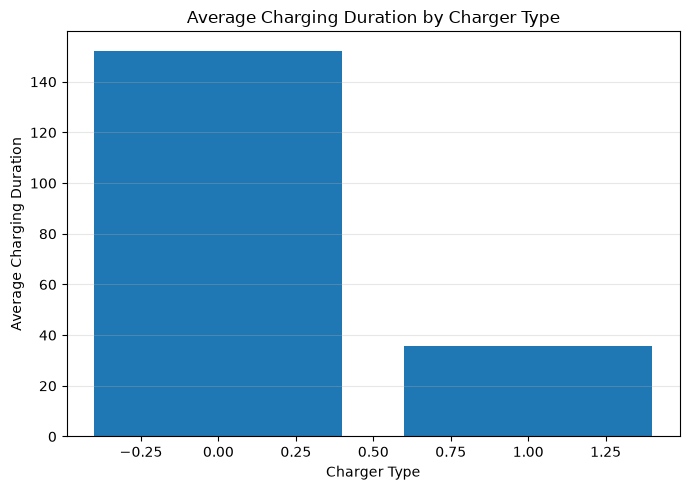

In [1552]:
# Visualize average charging duration by charger type

plt.figure(figsize=(7, 5))

plt.bar(
    charger_type_duration.index,
    charger_type_duration.values
)

plt.title("Average Charging Duration by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Average Charging Duration")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1553]:
print(df_final.columns.tolist())

['UserID', 'ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime', 'EndDatetime', 'Duration', 'Demand', 'StartHour', 'StartDayOfWeek', 'StartMonth']


In [1554]:
print([col for col in df_final.columns if "Day" in col])

['StartDay', 'EndDay', 'StartDayOfWeek']


In [1555]:
for i, col in enumerate(df_final.columns):
    print(i, repr(col))

0 'UserID'
1 'ChargerID'
2 'ChargerCompany'
3 'Location'
4 'ChargerType'
5 'StartDay'
6 'StartTime'
7 'EndDay'
8 'EndTime'
9 'StartDatetime'
10 'EndDatetime'
11 'Duration'
12 'Demand'
13 'StartHour'
14 'StartDayOfWeek'
15 'StartMonth'


In [1556]:
# Average charging demand by day of week

day = df_final.iloc[:, 14]
demand = df_final.iloc[:, 12]

daily_demand = demand.groupby(day).mean().sort_index()

print("Average Charging Demand by Day:")
print(daily_demand)

Average Charging Demand by Day:
StartDayOfWeek
Friday       15.946351
Monday       16.167384
Saturday     15.910383
Sunday       16.308228
Thursday     16.178026
Tuesday      15.869516
Wednesday    16.189731
Name: Demand, dtype: float64


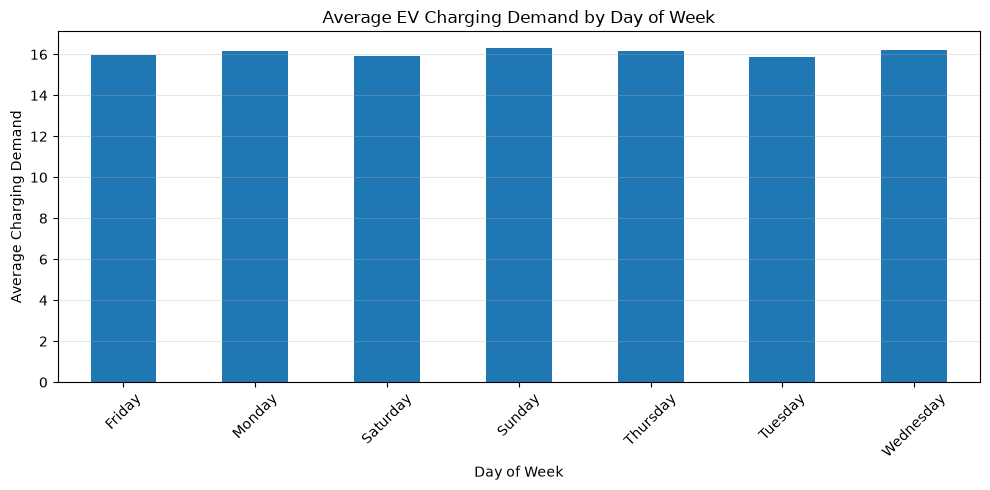

In [1557]:
# Average charging demand by day of week

plt.figure(figsize=(10, 5))

daily_demand.plot(kind="bar")

plt.title("Average EV Charging Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Charging Demand")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1558]:
# Average charging demand by hour

hourly_demand = (
    df_final.groupby(df_final.iloc[:, 13])["Demand"]
    .mean()
    .sort_index()
)

print("Average Charging Demand by Hour:")
print(hourly_demand)

Average Charging Demand by Hour:
StartHour
0     23.736887
1     23.166641
2     21.124651
3     18.123607
4     17.469454
5     16.080528
6     15.961329
7     16.337221
8     16.660703
9     13.892416
10    13.130141
11    13.572565
12    13.180108
13    13.484281
14    13.661314
15    13.388771
16    14.593910
17    15.774606
18    16.627361
19    18.002555
20    18.917432
21    20.259414
22    21.307660
23    24.112477
Name: Demand, dtype: float64


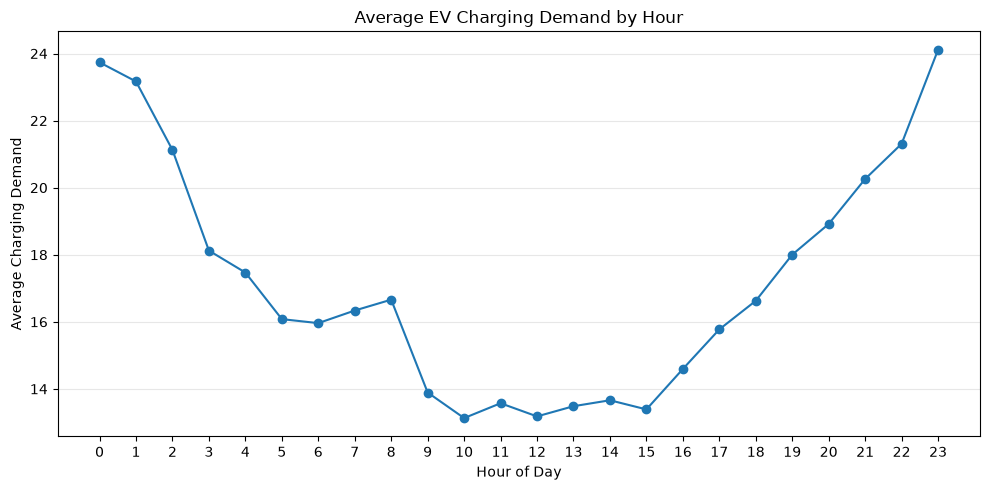

In [1559]:
# Visualize average charging demand by hour

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker='o'
)

plt.title("Average EV Charging Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Charging Demand")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1560]:
# Average charging demand by charger type

charger_demand = (
    df_final.groupby("ChargerType")["Demand"]
    .mean()
)

print("Average Charging Demand by Charger Type:")
print(charger_demand)

Average Charging Demand by Charger Type:
ChargerType
0    15.284283
1    18.946075
Name: Demand, dtype: float64


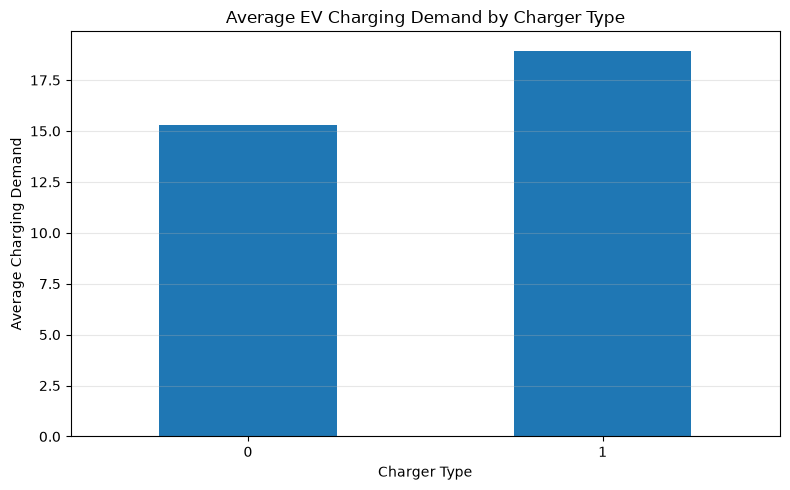

In [1561]:
# Visualize average charging demand by charger type

plt.figure(figsize=(8,5))

charger_demand.plot(kind="bar")

plt.title("Average EV Charging Demand by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Average Charging Demand")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1562]:
print(df_final["ChargerType"].value_counts())

ChargerType
0    53978
1    14926
Name: count, dtype: int64


In [1563]:
print(df_final.groupby("ChargerType")["Demand"].mean())

ChargerType
0    15.284283
1    18.946075
Name: Demand, dtype: float64


In [1564]:
print(df_final[["ChargerType", "ChargerID", "ChargerCompany"]].drop_duplicates().head(20))

      ChargerType  ChargerID  ChargerCompany
0               0          1               1
404             0          2               1
468             0          3               1
1017            0          5               1
1419            0          7               1
1449            0          8               1
1566            0          9               1
2013            0         10               1
2152            0         13               1
2658            0         14               1
2808            0         15               1
2854            0         16               1
3091            0         17               1
3252            0         18               1
3739            0         19               1
4248            0         20               1
4734            0         21               1
5109            0         22               1
5437            0         23               1
5587            0         24               1


In [1565]:
print(df_final.groupby("ChargerType")["ChargerCompany"].value_counts())

ChargerType  ChargerCompany
0            1                 42733
             0                 11245
1            0                 14926
Name: count, dtype: int64


In [1566]:
# Average charging demand by location

location_demand = (
    df_final.groupby("Location")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Charging Demand by Location:")
print(location_demand)

Average Charging Demand by Location:
Location
bus garage            28.587586
accommodation         26.666316
camping               21.544274
apartment             17.017893
public parking lot    16.802601
public area           16.366429
public institution    16.119585
restaurant            15.951280
resort                15.844724
golf                  15.786796
market                15.468510
company               15.254274
sightseeing           15.177073
hotel                 14.001854
Name: Demand, dtype: float64


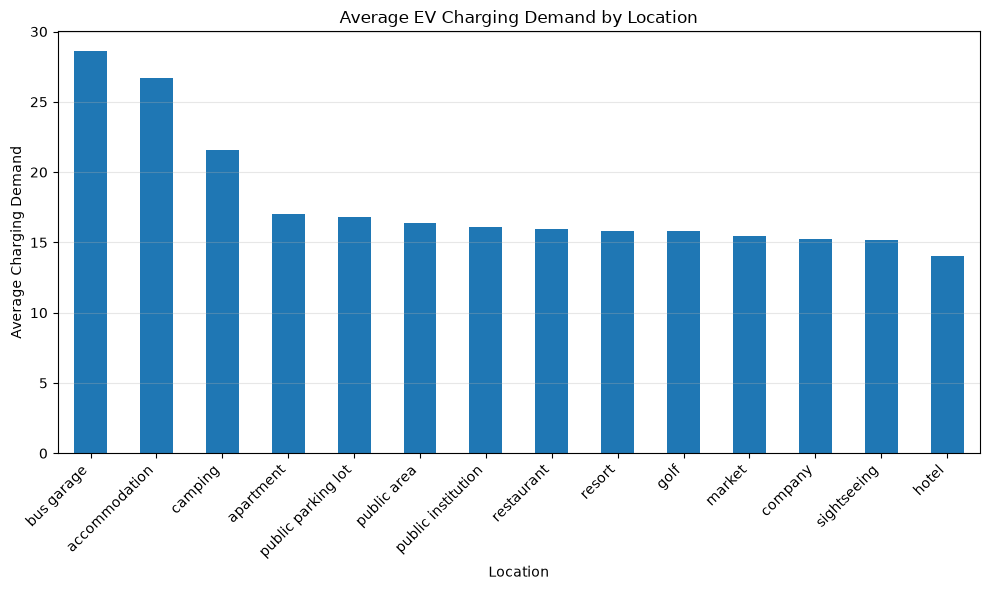

In [1567]:
# Visualize average charging demand by location

plt.figure(figsize=(10, 6))

location_demand.plot(kind="bar")

plt.title("Average EV Charging Demand by Location")
plt.xlabel("Location")
plt.ylabel("Average Charging Demand")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1568]:
company_demand = (
    df_final.groupby("ChargerCompany")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Charging Demand by Charger Company:")
print(company_demand)

Average Charging Demand by Charger Company:
ChargerCompany
1    16.107584
0    16.028381
Name: Demand, dtype: float64


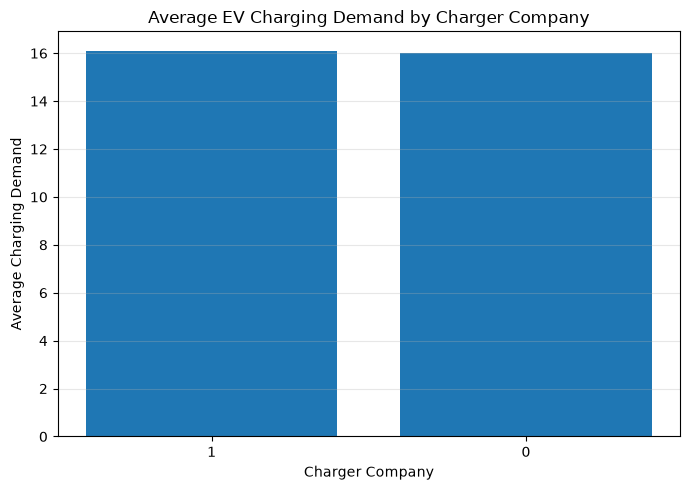

In [1569]:
plt.figure(figsize=(7, 5))

plt.bar(
    company_demand.index.astype(str),
    company_demand.values
)

plt.title("Average EV Charging Demand by Charger Company")
plt.xlabel("Charger Company")
plt.ylabel("Average Charging Demand")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1570]:
print(pd.crosstab(df_final["ChargerType"], df_final["ChargerCompany"]))

ChargerCompany      0      1
ChargerType                 
0               11245  42733
1               14926      0


In [1571]:
type_company_demand = (
    df_final.groupby(["ChargerType", "ChargerCompany"])["Demand"]
    .mean()
)

print("Average Demand by Charger Type and Company:")
print(type_company_demand)

Average Demand by Charger Type and Company:
ChargerType  ChargerCompany
0            0                 12.155593
             1                 16.107584
1            0                 18.946075
Name: Demand, dtype: float64


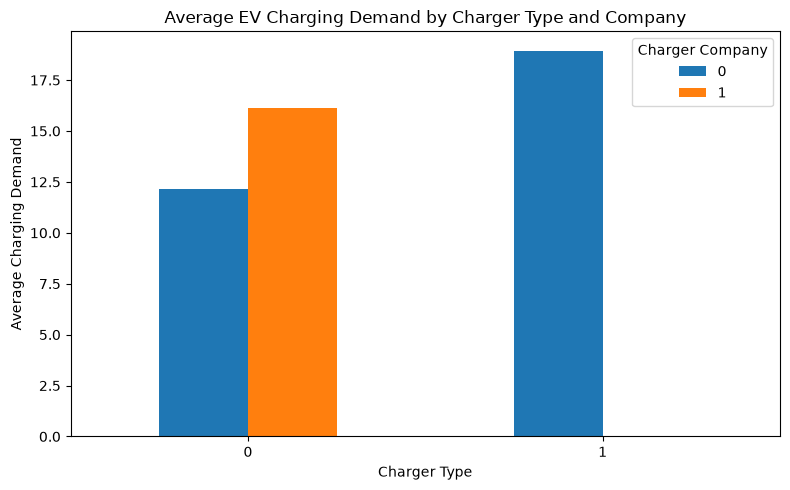

In [1572]:
type_company_plot = type_company_demand.unstack()

type_company_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average EV Charging Demand by Charger Type and Company")
plt.xlabel("Charger Type")
plt.ylabel("Average Charging Demand")
plt.xticks(rotation=0)
plt.legend(title="Charger Company")

plt.tight_layout()
plt.show()

In [1573]:
monthly_demand = (
    df_final.groupby("StartMonth")["Demand"]
    .mean()
    .sort_index()
)

print("Average Charging Demand by Month:")
print(monthly_demand)

Average Charging Demand by Month:
StartMonth
1     15.798678
2     16.255436
3     16.119631
4     16.191993
5     16.118578
6     16.384276
7     16.300231
8     16.150043
9     16.572147
10    15.404071
11    15.264168
12    15.708077
Name: Demand, dtype: float64


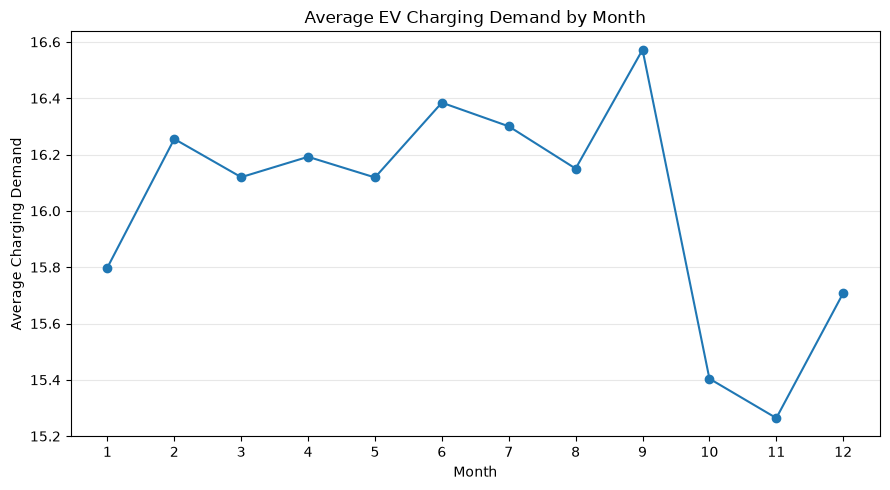

In [1574]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Average EV Charging Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Charging Demand")

plt.xticks(range(1, 13))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1575]:
# Correlation Analysis

correlation = df_final.corr(numeric_only=True)

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                  UserID  ChargerID  ChargerCompany  ChargerType  Duration  \
UserID          1.000000   0.386492       -0.295745     0.244427 -0.105367   
ChargerID       0.386492   1.000000       -0.713351     0.467942 -0.216745   
ChargerCompany -0.295745  -0.713351        1.000000    -0.671947  0.330159   
ChargerType     0.244427   0.467942       -0.671947     1.000000 -0.462382   
Duration       -0.105367  -0.216745        0.330159    -0.462382  1.000000   
Demand          0.007165  -0.001439        0.003291     0.129154  0.667536   
StartHour       0.002630  -0.080005        0.087590    -0.057552  0.128635   
StartMonth     -0.070145  -0.062328        0.060375    -0.030732 -0.002024   

                  Demand  StartHour  StartMonth  
UserID          0.007165   0.002630   -0.070145  
ChargerID      -0.001439  -0.080005   -0.062328  
ChargerCompany  0.003291   0.087590    0.060375  
ChargerType     0.129154  -0.057552   -0.030732  
Duration        0.667536   

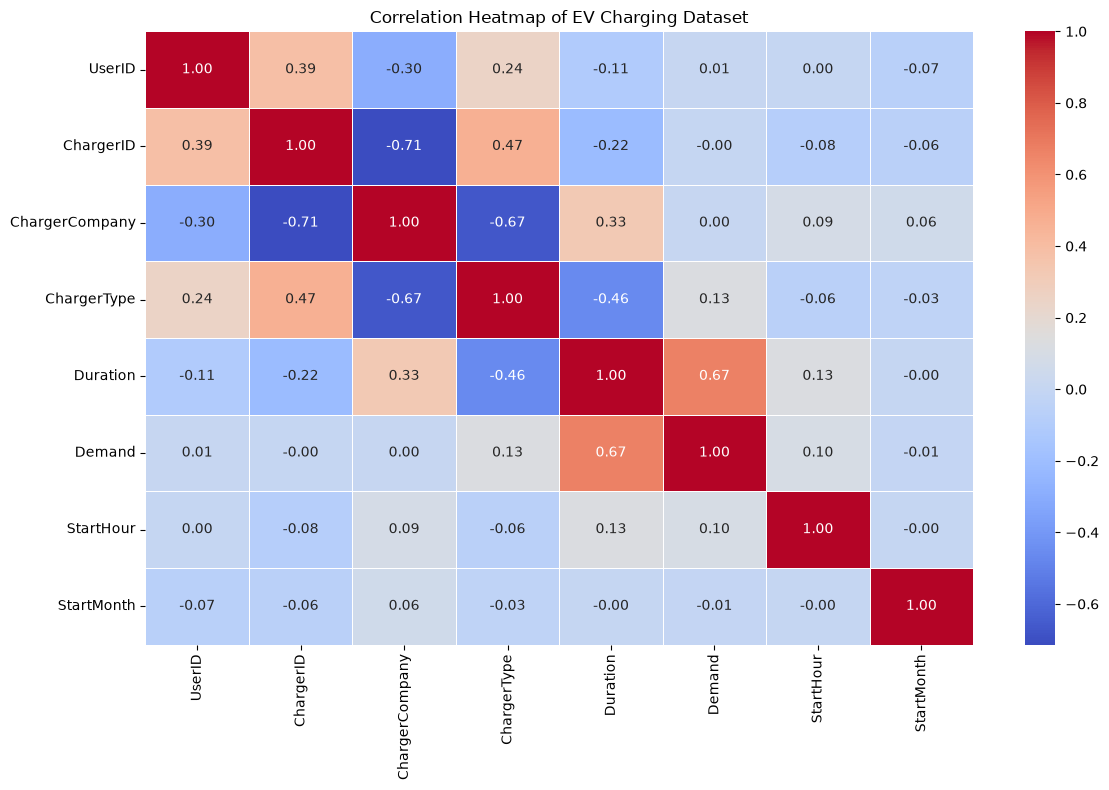

In [1576]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of EV Charging Dataset")
plt.tight_layout()
plt.show()

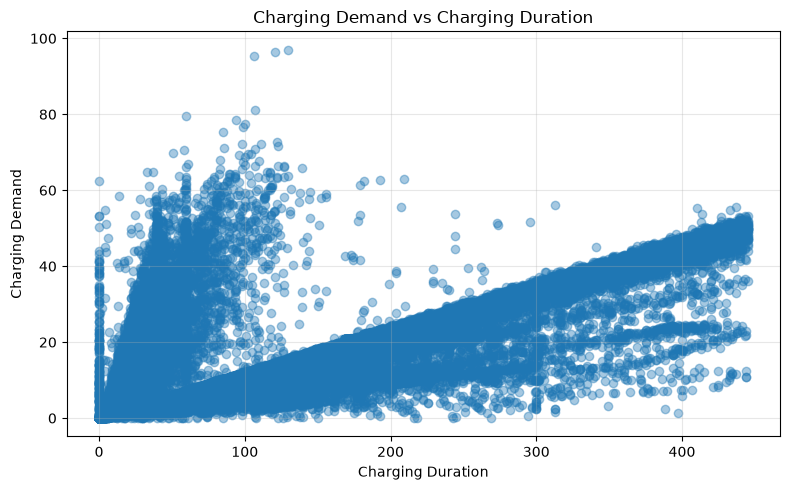

In [1577]:
plt.figure(figsize=(8, 5))

plt.scatter(df_final["Duration"], df_final["Demand"], alpha=0.4)

plt.title("Charging Demand vs Charging Duration")
plt.xlabel("Charging Duration")
plt.ylabel("Charging Demand")

plt.grid(axis="both", alpha=0.3)
plt.tight_layout()
plt.show()

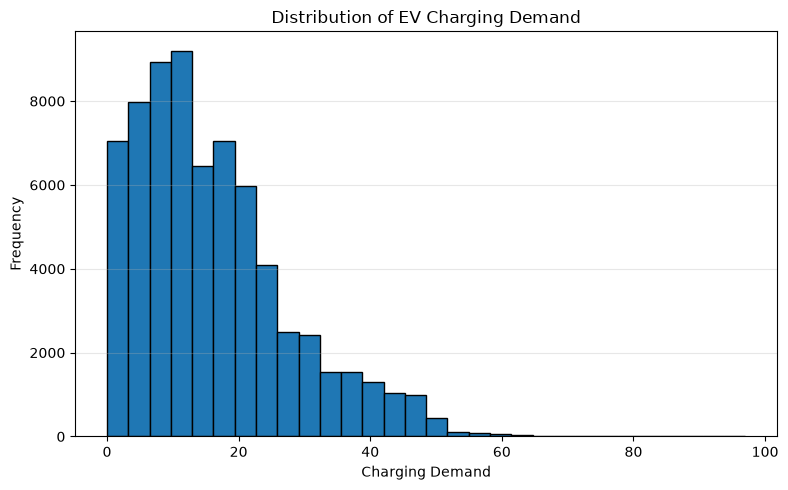

In [1578]:
plt.figure(figsize=(8, 5))

plt.hist(df_final["Demand"], bins=30, edgecolor="black")

plt.title("Distribution of EV Charging Demand")
plt.xlabel("Charging Demand")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

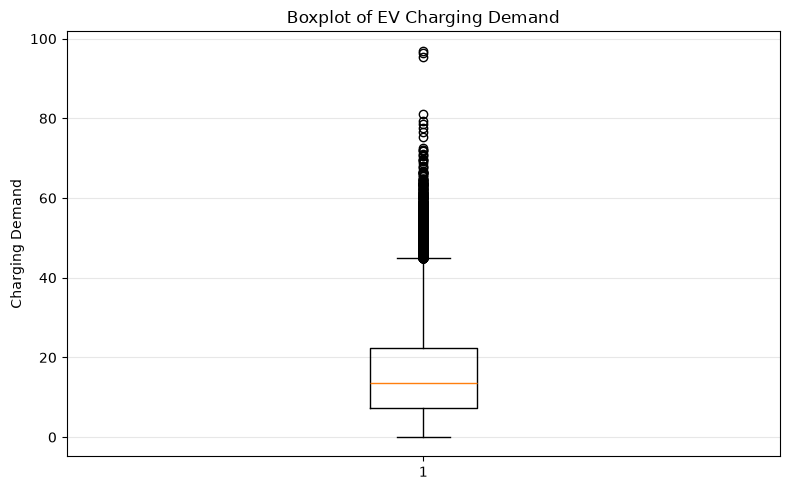

In [1579]:
plt.figure(figsize=(8, 5))

plt.boxplot(df_final["Demand"].dropna())

plt.title("Boxplot of EV Charging Demand")
plt.ylabel("Charging Demand")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [1580]:
print("Statistical Summary of Charging Demand:")
print(df_final["Demand"].describe())

Statistical Summary of Charging Demand:
count    68904.000000
mean        16.077501
std         11.679474
min          0.010000
25%          7.250000
50%         13.520000
75%         22.300000
max         97.000000
Name: Demand, dtype: float64


In [1581]:
# Distribution of charging sessions by location

location_counts = df_final["Location"].value_counts()

print("Charging Sessions by Location:")
print(location_counts)

Charging Sessions by Location:
Location
public area           13419
apartment             12690
resort                 8366
hotel                  8312
company                7253
public institution     6694
public parking lot     3352
market                 2885
restaurant             2093
camping                1439
sightseeing            1199
golf                   1002
accommodation           171
bus garage               29
Name: count, dtype: int64


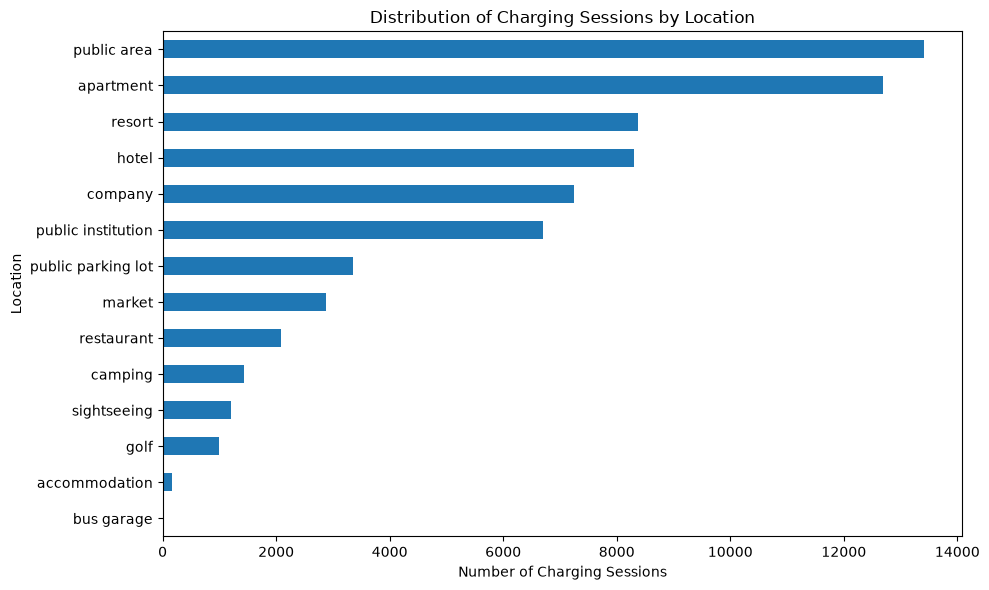

In [1582]:
plt.figure(figsize=(10, 6))

location_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Charging Sessions by Location")
plt.xlabel("Number of Charging Sessions")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [1583]:
# Distribution of charging sessions by charger type

charger_type_counts = df_final["ChargerType"].value_counts()

print("Charging Sessions by Charger Type:")
print(charger_type_counts)

Charging Sessions by Charger Type:
ChargerType
0    53978
1    14926
Name: count, dtype: int64


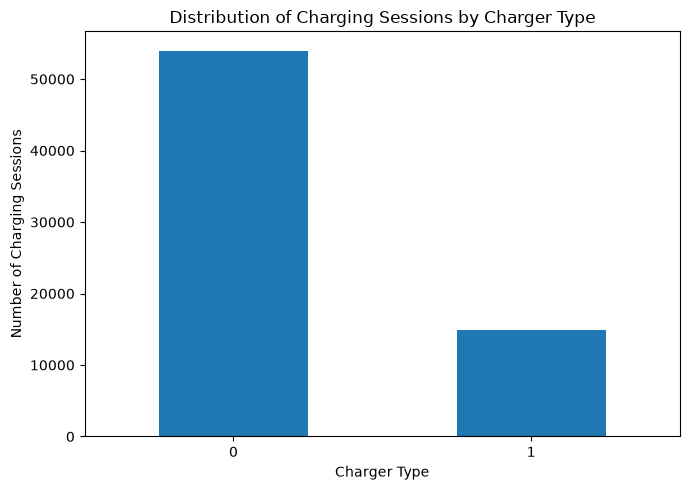

In [1584]:
plt.figure(figsize=(7, 5))

charger_type_counts.plot(kind="bar")

plt.title("Distribution of Charging Sessions by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Number of Charging Sessions")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [1585]:
# Distribution of charging sessions by charger company

company_counts = df_final["ChargerCompany"].value_counts()

print("Charging Sessions by Charger Company:")
print(company_counts)

Charging Sessions by Charger Company:
ChargerCompany
1    42733
0    26171
Name: count, dtype: int64


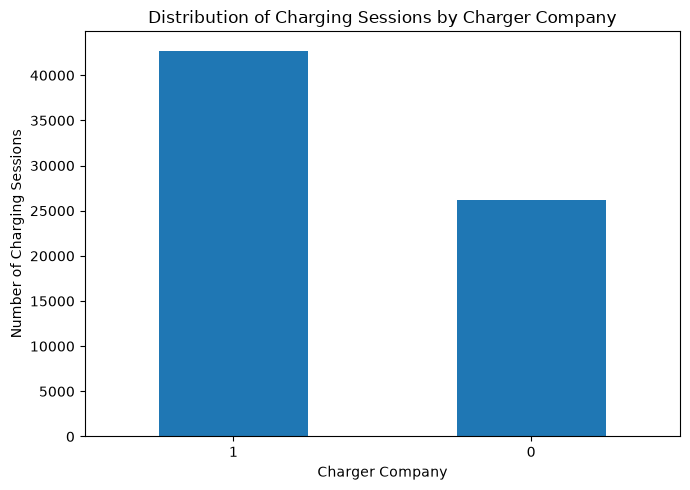

In [1586]:
plt.figure(figsize=(7, 5))

company_counts.plot(kind="bar")

plt.title("Distribution of Charging Sessions by Charger Company")
plt.xlabel("Charger Company")
plt.ylabel("Number of Charging Sessions")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [1587]:
type_company_counts = pd.crosstab(
    df_final["ChargerType"],
    df_final["ChargerCompany"]
)

print("Charging Sessions by Charger Type and Company:")
print(type_company_counts)

Charging Sessions by Charger Type and Company:
ChargerCompany      0      1
ChargerType                 
0               11245  42733
1               14926      0


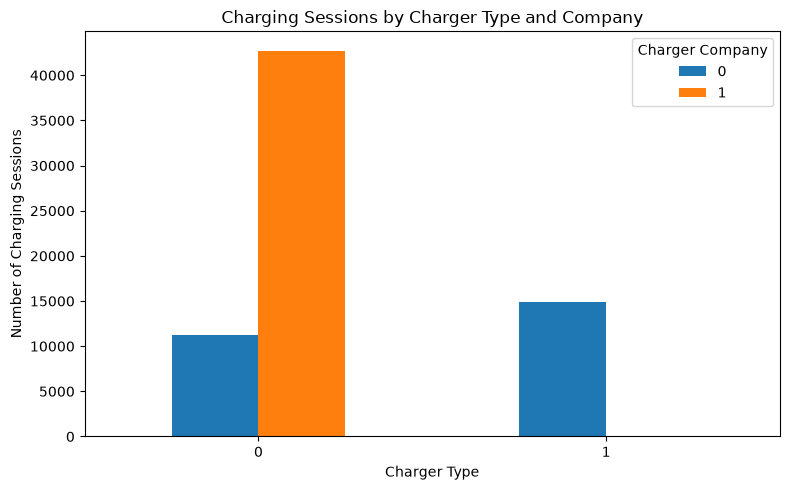

In [1588]:
type_company_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Charging Sessions by Charger Type and Company")
plt.xlabel("Charger Type")
plt.ylabel("Number of Charging Sessions")
plt.xticks(rotation=0)
plt.legend(title="Charger Company")

plt.tight_layout()
plt.show()

In [1589]:
type_company_demand = (
    df_final.groupby(["ChargerType", "ChargerCompany"])["Demand"]
    .mean()
)

print("Average Charging Demand by Charger Type and Company:")
print(type_company_demand)

Average Charging Demand by Charger Type and Company:
ChargerType  ChargerCompany
0            0                 12.155593
             1                 16.107584
1            0                 18.946075
Name: Demand, dtype: float64


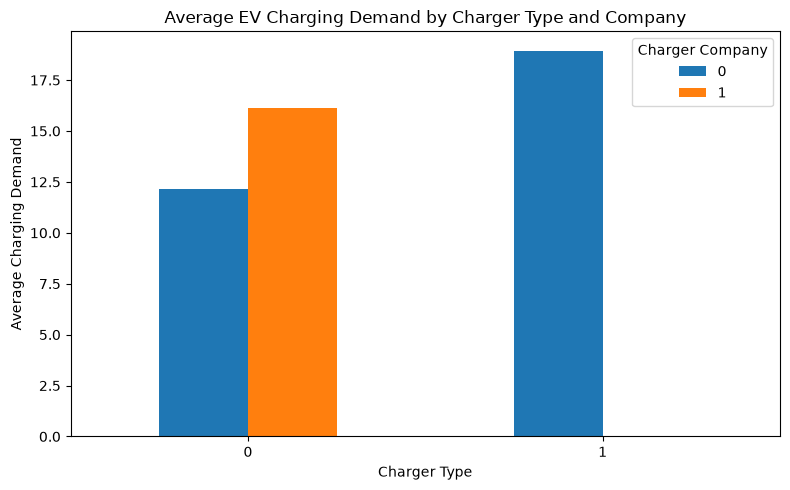

In [1590]:
type_company_demand.unstack().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average EV Charging Demand by Charger Type and Company")
plt.xlabel("Charger Type")
plt.ylabel("Average Charging Demand")
plt.xticks(rotation=0)
plt.legend(title="Charger Company")

plt.tight_layout()
plt.show()

In [1591]:
hourly_demand = (
    df_final.groupby("StartHour")["Demand"]
    .mean()
    .sort_index()
)

print("Average Charging Demand by Hour:")
print(hourly_demand)

Average Charging Demand by Hour:
StartHour
0     23.736887
1     23.166641
2     21.124651
3     18.123607
4     17.469454
5     16.080528
6     15.961329
7     16.337221
8     16.660703
9     13.892416
10    13.130141
11    13.572565
12    13.180108
13    13.484281
14    13.661314
15    13.388771
16    14.593910
17    15.774606
18    16.627361
19    18.002555
20    18.917432
21    20.259414
22    21.307660
23    24.112477
Name: Demand, dtype: float64


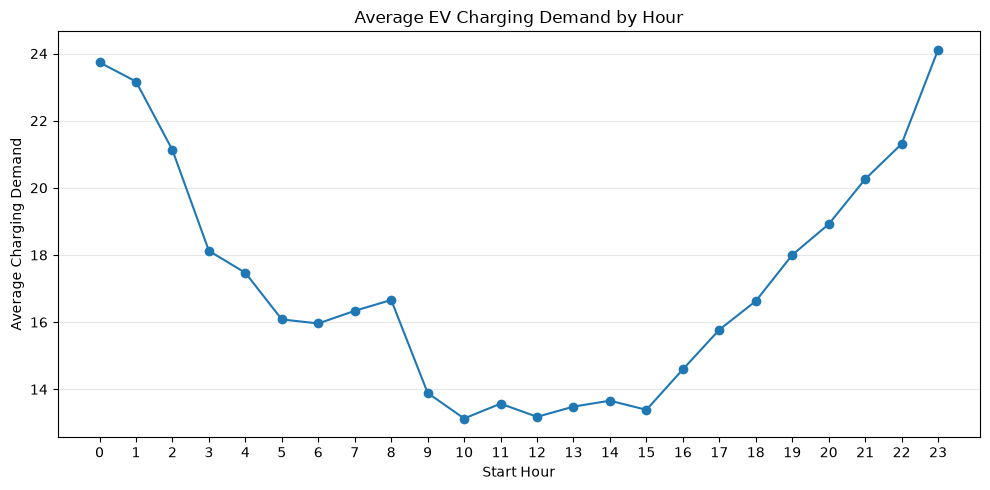

In [1592]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.title("Average EV Charging Demand by Hour")
plt.xlabel("Start Hour")
plt.ylabel("Average Charging Demand")

plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

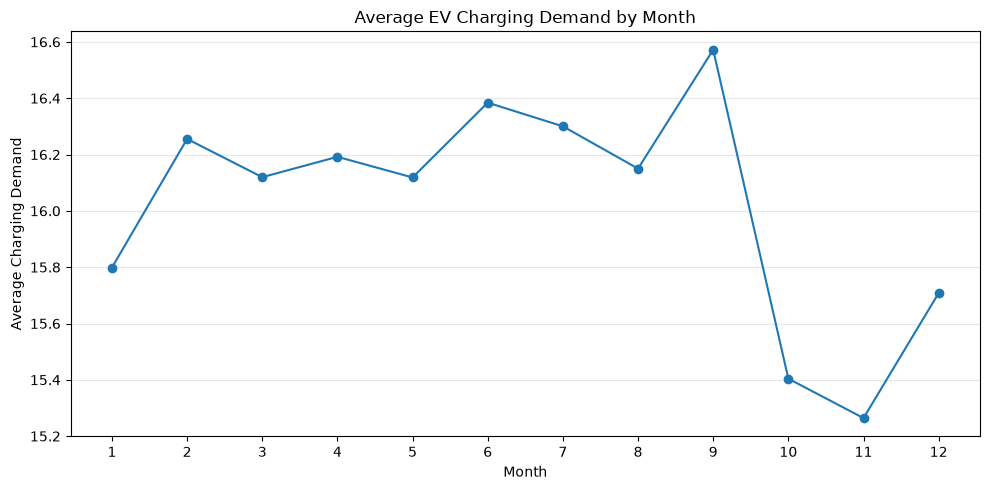

In [1593]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Average EV Charging Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Charging Demand")

plt.xticks(range(1, 13))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1594]:
duration_demand = (
    df_final.groupby("Duration")["Demand"]
    .mean()
    .sort_index()
)

print("Average Charging Demand by Duration:")
print(duration_demand.head(20))

Average Charging Demand by Duration:
Duration
0     4.242368
1     0.170564
2     0.402118
3     0.553231
4     1.793454
5     1.813891
6     1.959186
7     2.406009
8     3.067874
9     3.678981
10    3.753455
11    4.306122
12    4.688452
13    5.342958
14    5.945196
15    6.273415
16    6.397853
17    7.568826
18    7.345240
19    7.645329
Name: Demand, dtype: float64


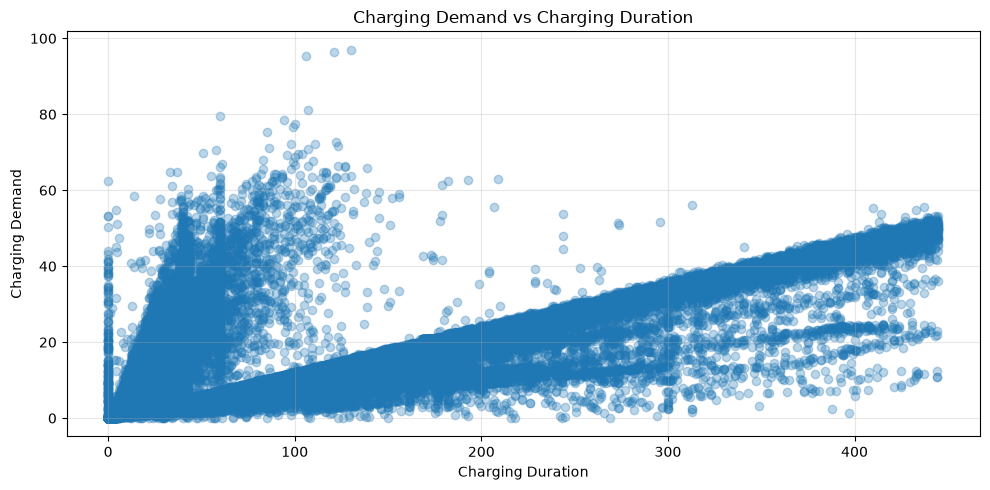

In [1595]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_final["Duration"],
    df_final["Demand"],
    alpha=0.3
)

plt.title("Charging Demand vs Charging Duration")
plt.xlabel("Charging Duration")
plt.ylabel("Charging Demand")

plt.grid(axis="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [1596]:
# Outlier Analysis using IQR

Q1 = df_final["Demand"].quantile(0.25)
Q3 = df_final["Demand"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_final[
    (df_final["Demand"] < lower_bound) |
    (df_final["Demand"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Q1: 7.25
Q3: 22.3
IQR: 15.05
Lower Bound: -15.325000000000003
Upper Bound: 44.875
Number of Outliers: 1877


In [1597]:
# Outlier percentage

outlier_percentage = (len(outliers) / len(df_final)) * 100

print("Total Records:", len(df_final))
print("Number of Outliers:", len(outliers))
print("Outlier Percentage:", round(outlier_percentage, 2), "%")

Total Records: 68904
Number of Outliers: 1877
Outlier Percentage: 2.72 %


In [1598]:
print("Minimum Outlier Demand:", outliers["Demand"].min())
print("Maximum Outlier Demand:", outliers["Demand"].max())

print("\nSample Outlier Records:")
print(outliers[["Demand", "Duration", "ChargerType", "ChargerCompany"]].head(10))

Minimum Outlier Demand: 44.88
Maximum Outlier Demand: 97.0

Sample Outlier Records:
     Demand  Duration  ChargerType  ChargerCompany
28    45.83       403            0               1
154   47.05       426            0               1
171   45.57       402            0               1
191   45.12       422            0               1
194   49.57       442            0               1
362   55.28       410            0               1
385   56.13       313            0               1
427   47.41       421            0               1
552   45.45       421            0               1
638   45.00       419            0               1


In [1599]:
# Compare demand with and without outliers

demand_with_outliers = df_final["Demand"].mean()
demand_without_outliers = df_final[
    df_final["Demand"] <= upper_bound
]["Demand"].mean()

print("Average Demand with Outliers:", round(demand_with_outliers, 2))
print("Average Demand without Outliers:", round(demand_without_outliers, 2))

Average Demand with Outliers: 16.08
Average Demand without Outliers: 15.15


In [1600]:
# Average Charging Demand by Location

location_demand = (
    df_final.groupby("Location")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Charging Demand by Location:")
print(location_demand)

Average Charging Demand by Location:
Location
bus garage            28.587586
accommodation         26.666316
camping               21.544274
apartment             17.017893
public parking lot    16.802601
public area           16.366429
public institution    16.119585
restaurant            15.951280
resort                15.844724
golf                  15.786796
market                15.468510
company               15.254274
sightseeing           15.177073
hotel                 14.001854
Name: Demand, dtype: float64


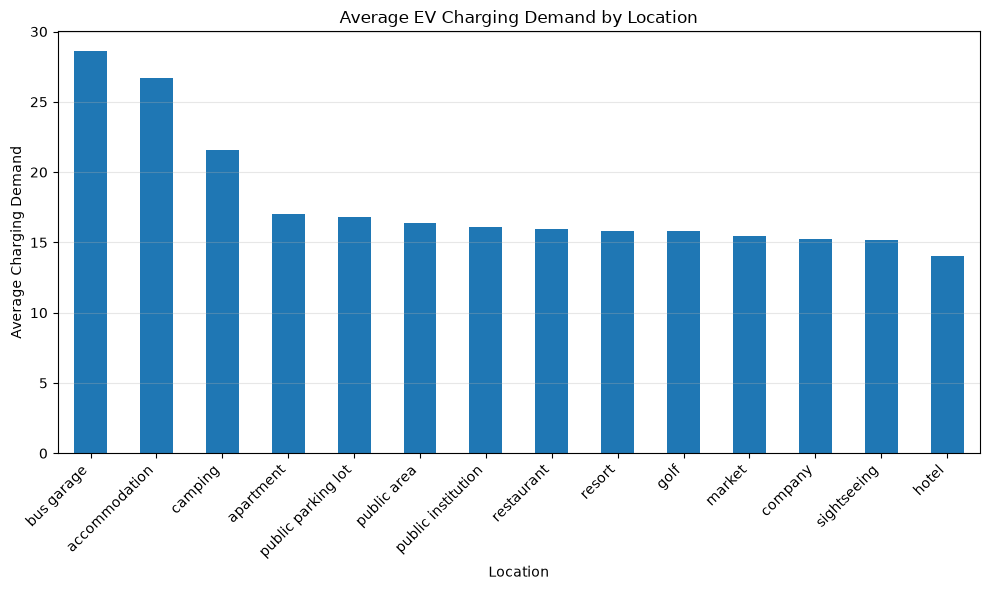

In [1601]:
# Average Charging Demand by Location - Bar Chart

plt.figure(figsize=(10, 6))

location_demand.plot(kind="bar")

plt.title("Average EV Charging Demand by Location")
plt.xlabel("Location")
plt.ylabel("Average Charging Demand")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1602]:
# Charging Demand by Charger Type and Company

charger_analysis = (
    df_final.groupby(["ChargerType", "ChargerCompany"])["Demand"]
    .mean()
    .reset_index()
)

print("Average Charging Demand by Charger Type and Company:")
print(charger_analysis)

Average Charging Demand by Charger Type and Company:
   ChargerType  ChargerCompany     Demand
0            0               0  12.155593
1            0               1  16.107584
2            1               0  18.946075


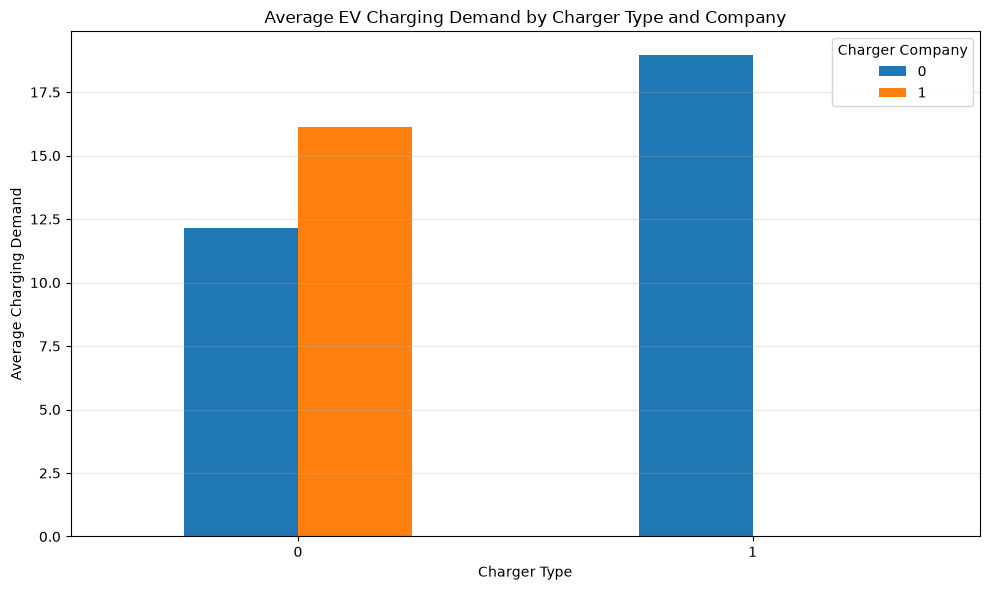

In [1603]:
# Average Charging Demand by Charger Type and Company

pivot_demand = charger_analysis.pivot(
    index="ChargerType",
    columns="ChargerCompany",
    values="Demand"
)

pivot_demand.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average EV Charging Demand by Charger Type and Company")
plt.xlabel("Charger Type")
plt.ylabel("Average Charging Demand")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Charger Company")

plt.tight_layout()
plt.show()

In [1604]:
# Average Charging Demand by Start Hour

hourly_demand = (
    df_final.groupby("StartHour")["Demand"]
    .mean()
)

print("Average Charging Demand by Start Hour:")
print(hourly_demand)

Average Charging Demand by Start Hour:
StartHour
0     23.736887
1     23.166641
2     21.124651
3     18.123607
4     17.469454
5     16.080528
6     15.961329
7     16.337221
8     16.660703
9     13.892416
10    13.130141
11    13.572565
12    13.180108
13    13.484281
14    13.661314
15    13.388771
16    14.593910
17    15.774606
18    16.627361
19    18.002555
20    18.917432
21    20.259414
22    21.307660
23    24.112477
Name: Demand, dtype: float64


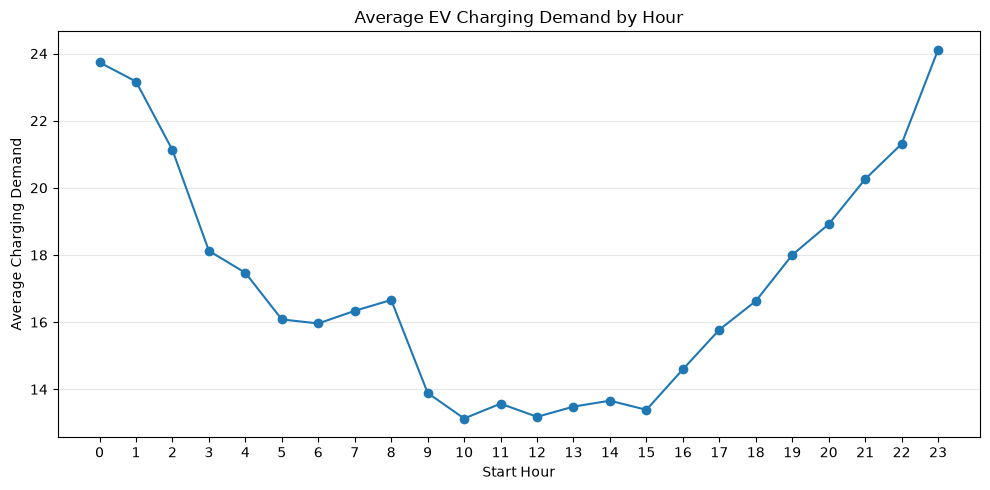

In [1605]:
# Average EV Charging Demand by Start Hour

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.title("Average EV Charging Demand by Hour")
plt.xlabel("Start Hour")
plt.ylabel("Average Charging Demand")

plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1606]:
# Average Charging Demand by Month

monthly_demand = (
    df_final.groupby("StartMonth")["Demand"]
    .mean()
    .sort_index()
)

print("Average Charging Demand by Month:")
print(monthly_demand)

Average Charging Demand by Month:
StartMonth
1     15.798678
2     16.255436
3     16.119631
4     16.191993
5     16.118578
6     16.384276
7     16.300231
8     16.150043
9     16.572147
10    15.404071
11    15.264168
12    15.708077
Name: Demand, dtype: float64


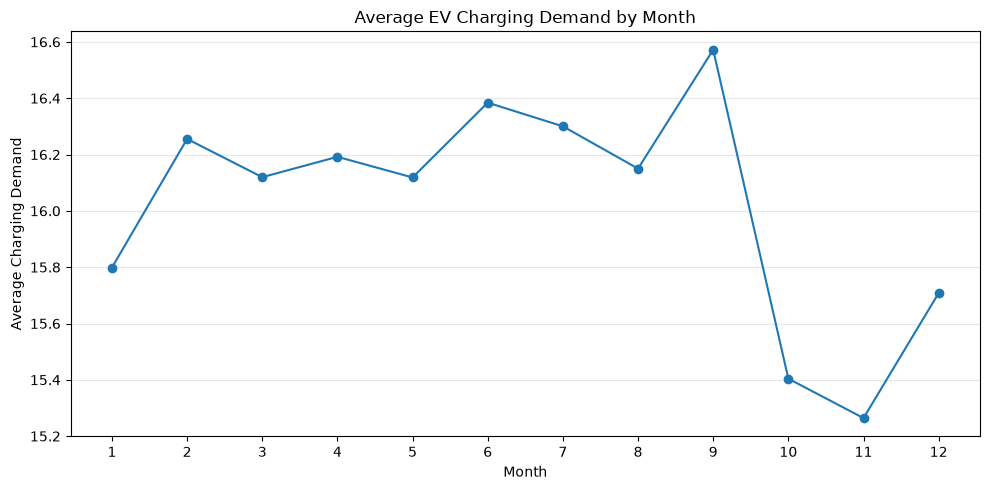

In [1607]:
# Average EV Charging Demand by Month - Line Chart

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Average EV Charging Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Charging Demand")

plt.xticks(range(1, 13))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [1608]:
print("Target column:")
print(df_final.columns[12])

print("\nNumeric columns:")
print(df_final.select_dtypes(include="number").columns.tolist())

Target column:
Demand

Numeric columns:
['UserID', 'ChargerID', 'ChargerCompany', 'ChargerType', 'Duration', 'Demand', 'StartHour', 'StartMonth']


In [1609]:
X = df_final[
    ["Duration", "ChargerType", "ChargerCompany", "StartHour", "StartMonth"]
]

y = df_final["Demand"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):
   Duration  ChargerType  ChargerCompany  StartHour  StartMonth
0       185            0               1         20           9
1        90            0               1         20           9
2        60            0               1         18           9
3       344            0               1         18           9
4       300            0               1         19           9

Target (y):
0    20.36
1    10.19
2     6.78
3    37.65
4    33.81
Name: Demand, dtype: float64

X shape: (68904, 5)
y shape: (68904,)


In [1610]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (55123, 5)
X_test shape: (13781, 5)
y_train shape: (55123,)
y_test shape: (13781,)


In [1611]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Linear Regression model trained successfully!")
print("First 5 predictions:", y_pred_lr[:5])

Linear Regression model trained successfully!
First 5 predictions: [12.56064208  2.72810419 16.4131376  35.32790477  3.09802086]


In [1612]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Performance:
MAE : 3.7944432571631466
MSE : 40.51066901224589
RMSE: 6.364799212249031
R²  : 0.6996928097726955


In [1613]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest model trained successfully!")
print("First 5 predictions:", y_pred_rf[:5])

Random Forest model trained successfully!
First 5 predictions: [13.38333667  2.63983333 11.09386667 35.8873      2.84787333]


In [1614]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Performance:
MAE : 3.377804692140529
MSE : 34.130241466449085
RMSE: 5.84210933366101
R²  : 0.7469911713018009


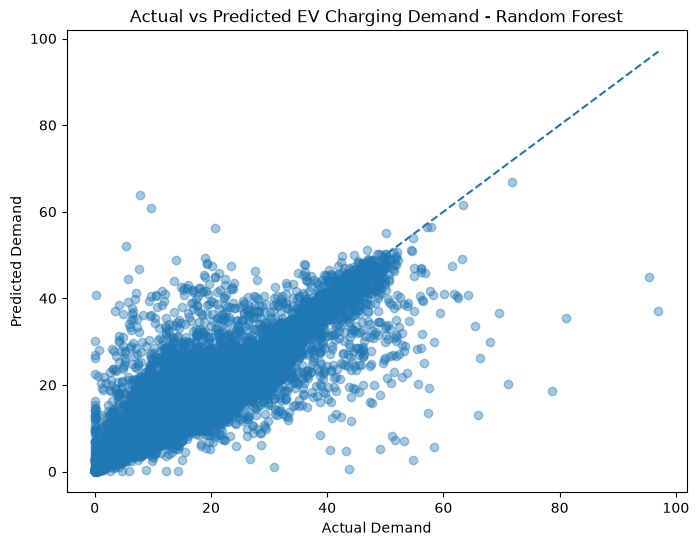

In [1615]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.4)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted EV Charging Demand - Random Forest")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [1616]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

          Feature  Importance
0        Duration    0.771199
1     ChargerType    0.092876
3       StartHour    0.065642
4      StartMonth    0.056367
2  ChargerCompany    0.013917


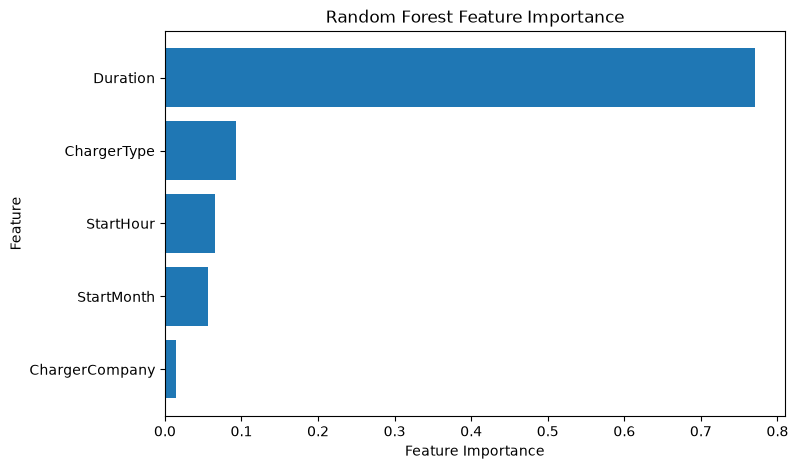

In [1617]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [1618]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "MSE": [mse_lr, mse_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

print(model_comparison)

               Model       MAE        MSE      RMSE        R2
0  Linear Regression  3.794443  40.510669  6.364799  0.699693
1      Random Forest  3.377805  34.130241  5.842109  0.746991


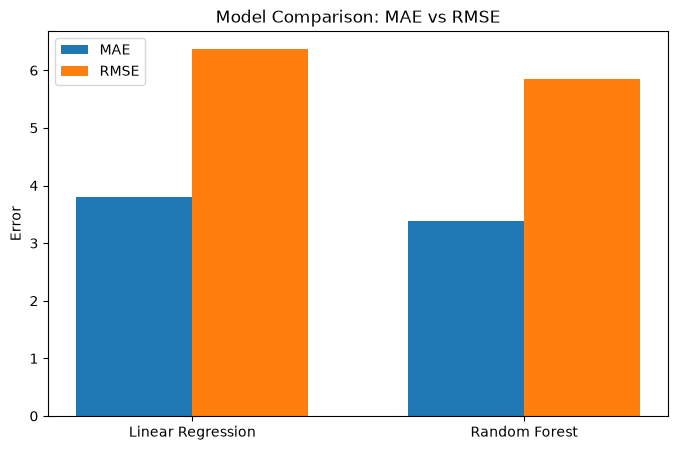

In [1619]:
plt.figure(figsize=(8, 5))

x = np.arange(len(model_comparison["Model"]))
width = 0.35

plt.bar(
    x - width/2,
    model_comparison["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width/2,
    model_comparison["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(x, model_comparison["Model"])
plt.ylabel("Error")
plt.title("Model Comparison: MAE vs RMSE")
plt.legend()

plt.show()

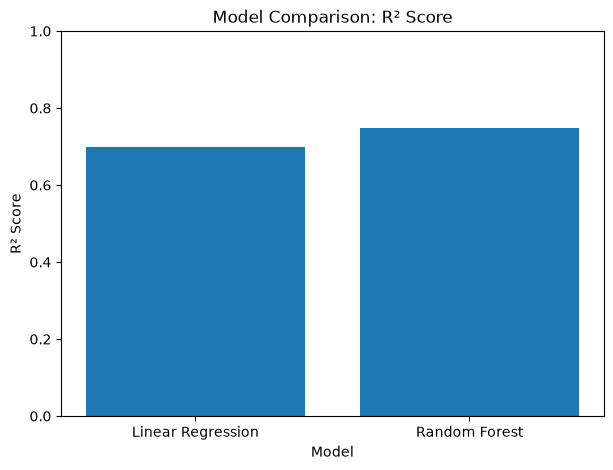

In [1620]:
plt.figure(figsize=(7, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2"]
)

plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Model Comparison: R² Score")
plt.ylim(0, 1)

plt.show()

In [1621]:
q1_demand = df_final["Demand"].quantile(0.33)
q2_demand = df_final["Demand"].quantile(0.66)

print("Low Demand: <=", q1_demand)
print("Medium Demand:", q1_demand, "to", q2_demand)
print("High Demand: >", q2_demand)

Low Demand: <= 9.29
Medium Demand: 9.29 to 18.62
High Demand: > 18.62


In [1622]:
df_final["DemandLevel"] = pd.cut(
    df_final["Demand"],
    bins=[-float("inf"), q1_demand, q2_demand, float("inf")],
    labels=["Low", "Medium", "High"]
)

print(df_final["DemandLevel"].value_counts())

DemandLevel
High      23427
Low       22762
Medium    22715
Name: count, dtype: int64


In [1623]:
demand_percentage = (
    df_final["DemandLevel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Demand Level Percentage:")
print(demand_percentage)

Demand Level Percentage:
DemandLevel
High      34.00
Low       33.03
Medium    32.97
Name: proportion, dtype: float64


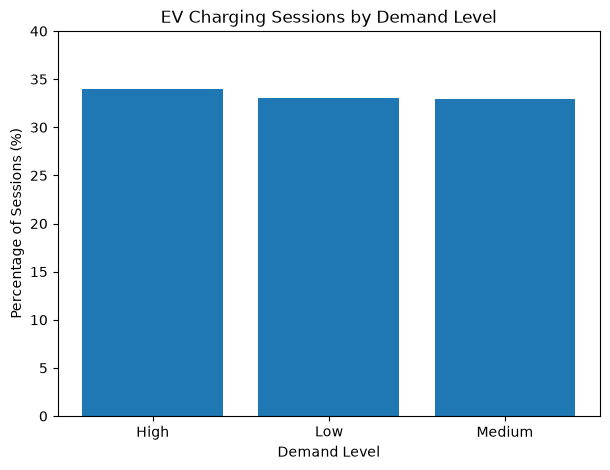

In [1624]:
plt.figure(figsize=(7, 5))

plt.bar(
    demand_percentage.index,
    demand_percentage.values
)

plt.xlabel("Demand Level")
plt.ylabel("Percentage of Sessions (%)")
plt.title("EV Charging Sessions by Demand Level")

plt.ylim(0, 40)

plt.show()

In [1625]:
demand_charger = pd.crosstab(
    df_final["ChargerType"],
    df_final["DemandLevel"],
    normalize="index"
).mul(100).round(2)

print("Demand Level Distribution by Charger Type (%):")
print(demand_charger)

Demand Level Distribution by Charger Type (%):
DemandLevel    Low  Medium   High
ChargerType                      
0            36.04   33.02  30.93
1            22.16   32.75  45.09


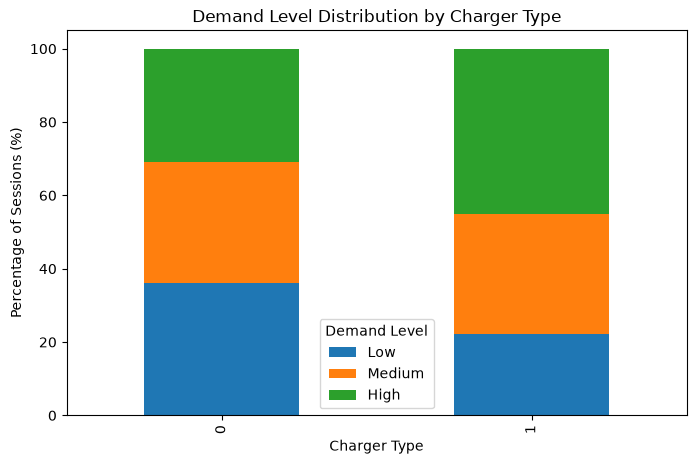

In [1626]:
demand_charger.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.xlabel("Charger Type")
plt.ylabel("Percentage of Sessions (%)")
plt.title("Demand Level Distribution by Charger Type")
plt.legend(title="Demand Level")

plt.show()

In [1627]:
demand_location = pd.crosstab(
    df_final["Location"],
    df_final["DemandLevel"],
    normalize="index"
).mul(100).round(2)

print("Demand Level Distribution by Location (%):")
print(demand_location)

Demand Level Distribution by Location (%):
DemandLevel           Low  Medium   High
Location                                
accommodation       10.53   11.70  77.78
apartment           29.65   34.78  35.56
bus garage          13.79   24.14  62.07
camping             20.01   24.74  55.25
company             30.83   38.74  30.43
golf                34.43   32.83  32.73
hotel               39.15   34.28  26.58
market              44.44   23.67  31.89
public area         33.16   31.35  35.49
public institution  31.71   31.74  36.54
public parking lot  25.21   35.62  39.17
resort              35.86   30.58  33.56
restaurant          31.72   40.18  28.09
sightseeing         40.87   26.86  32.28


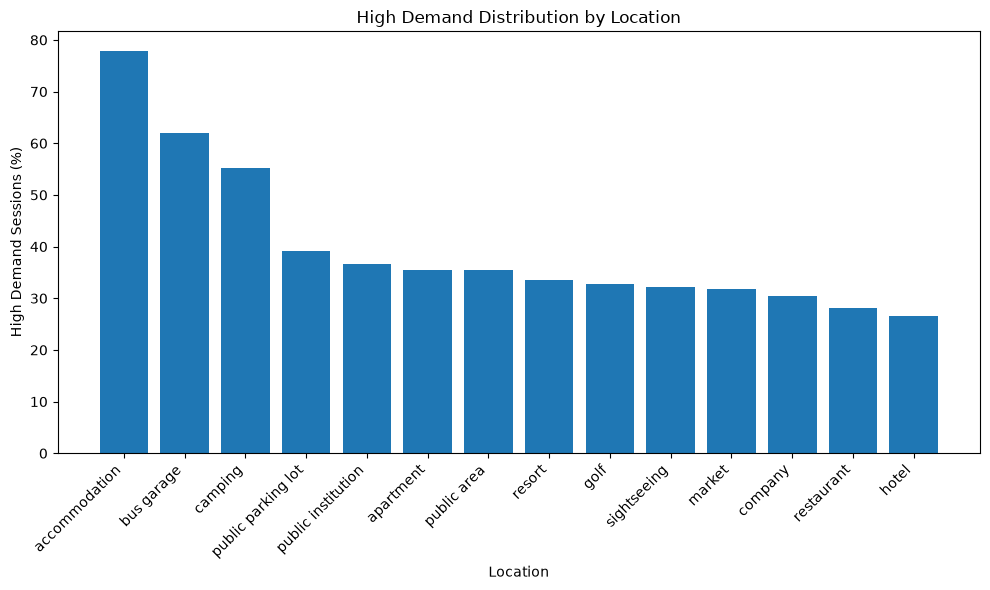

In [1628]:
high_demand_location = demand_location["High"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    high_demand_location.index,
    high_demand_location.values
)

plt.xlabel("Location")
plt.ylabel("High Demand Sessions (%)")
plt.title("High Demand Distribution by Location")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [1629]:
demand_hour = pd.crosstab(
    df_final["StartHour"],
    df_final["DemandLevel"],
    normalize="index"
).mul(100).round(2)

print("Demand Level Distribution by Hour (%):")
print(demand_hour)

Demand Level Distribution by Hour (%):
DemandLevel    Low  Medium   High
StartHour                        
0            15.25   26.94  57.81
1            15.78   26.46  57.76
2            18.60   32.56  48.84
3            18.85   36.89  44.26
4            20.22   41.53  38.25
5            20.38   47.55  32.08
6            25.19   43.92  30.89
7            29.26   34.81  35.93
8            29.41   35.14  35.44
9            35.59   40.30  24.11
10           43.33   33.13  23.54
11           43.39   30.77  25.84
12           44.76   30.12  25.12
13           41.79   32.11  26.10
14           42.11   30.65  27.24
15           42.20   33.68  24.12
16           37.97   33.57  28.46
17           33.00   34.47  32.53
18           30.33   33.64  36.03
19           26.26   31.83  41.91
20           24.40   31.01  44.59
21           21.16   30.18  48.65
22           19.91   28.67  51.42
23           15.60   23.90  60.51


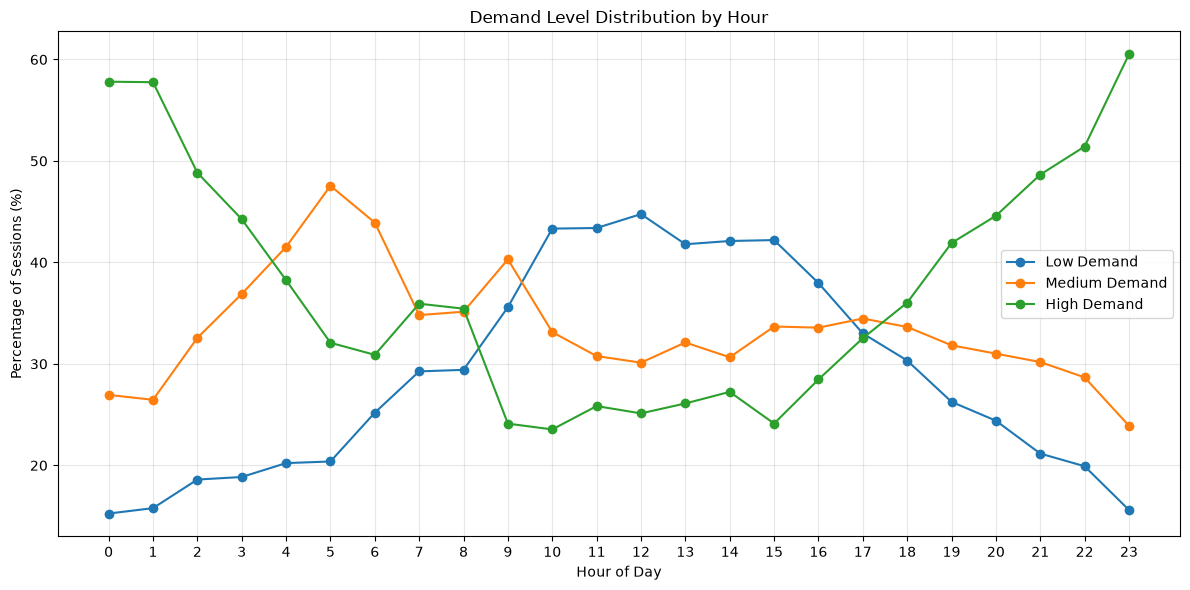

In [1630]:
plt.figure(figsize=(12, 6))

plt.plot(demand_hour.index, demand_hour["Low"], marker="o", label="Low Demand")
plt.plot(demand_hour.index, demand_hour["Medium"], marker="o", label="Medium Demand")
plt.plot(demand_hour.index, demand_hour["High"], marker="o", label="High Demand")

plt.title("Demand Level Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Percentage of Sessions (%)")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1631]:
demand_company = pd.crosstab(
    df_final["ChargerCompany"],
    df_final["DemandLevel"],
    normalize="index"
).mul(100).round(2)

print("Demand Level Distribution by Charger Company (%):")
print(demand_company)

Demand Level Distribution by Charger Company (%):
DemandLevel       Low  Medium   High
ChargerCompany                      
0               31.28   34.55  34.17
1               34.11   32.00  33.89


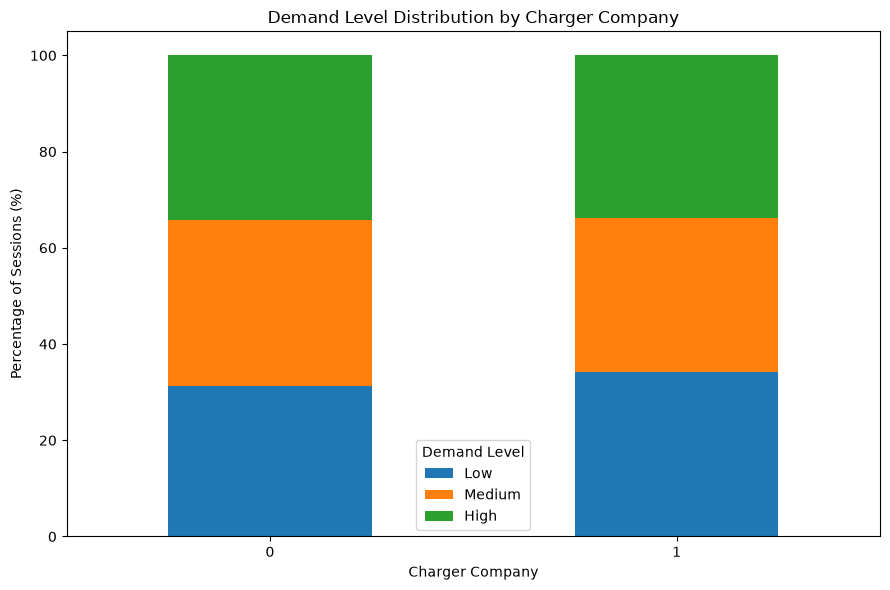

In [1632]:
demand_company.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Demand Level Distribution by Charger Company")
plt.xlabel("Charger Company")
plt.ylabel("Percentage of Sessions (%)")
plt.xticks(rotation=0)
plt.legend(title="Demand Level")
plt.tight_layout()
plt.show()

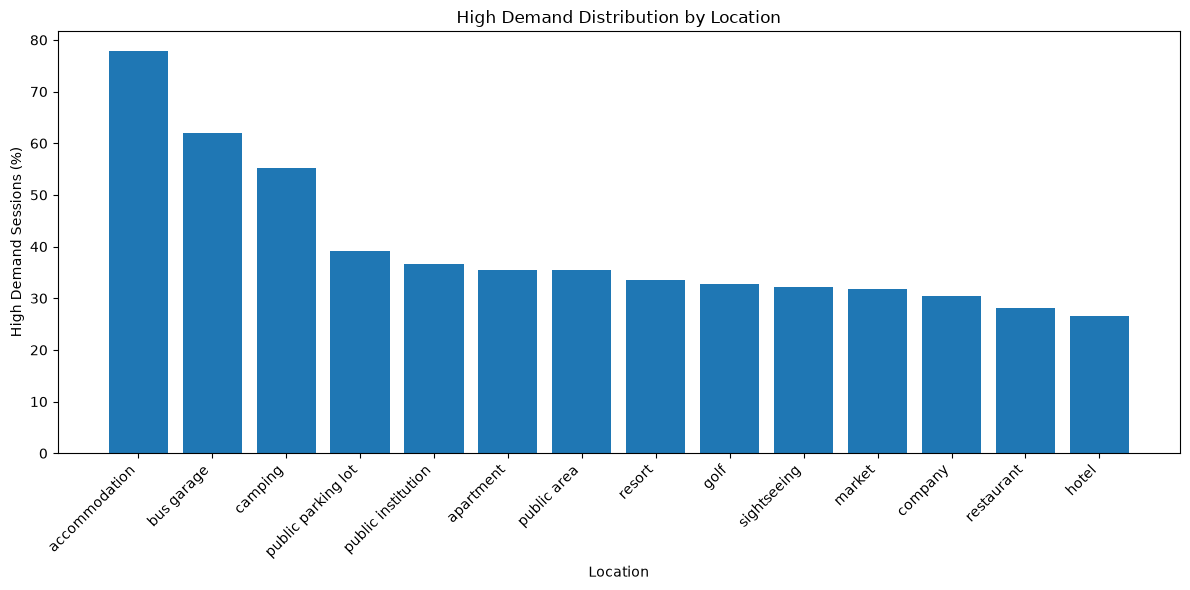

In [1633]:
high_demand_location = demand_location["High"].sort_values(ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(high_demand_location.index, high_demand_location.values)

plt.title("High Demand Distribution by Location")
plt.xlabel("Location")
plt.ylabel("High Demand Sessions (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [1634]:
errors_rf = y_test - y_pred_rf

print("Random Forest Error Analysis:")
print("Mean Error:", errors_rf.mean())
print("Minimum Error:", errors_rf.min())
print("Maximum Error:", errors_rf.max())
print("Mean Absolute Error:", np.abs(errors_rf).mean())

Random Forest Error Analysis:
Mean Error: 0.018228082393567335
Minimum Error: -56.186500000000066
Maximum Error: 60.01153333333333
Mean Absolute Error: 3.377804692140529


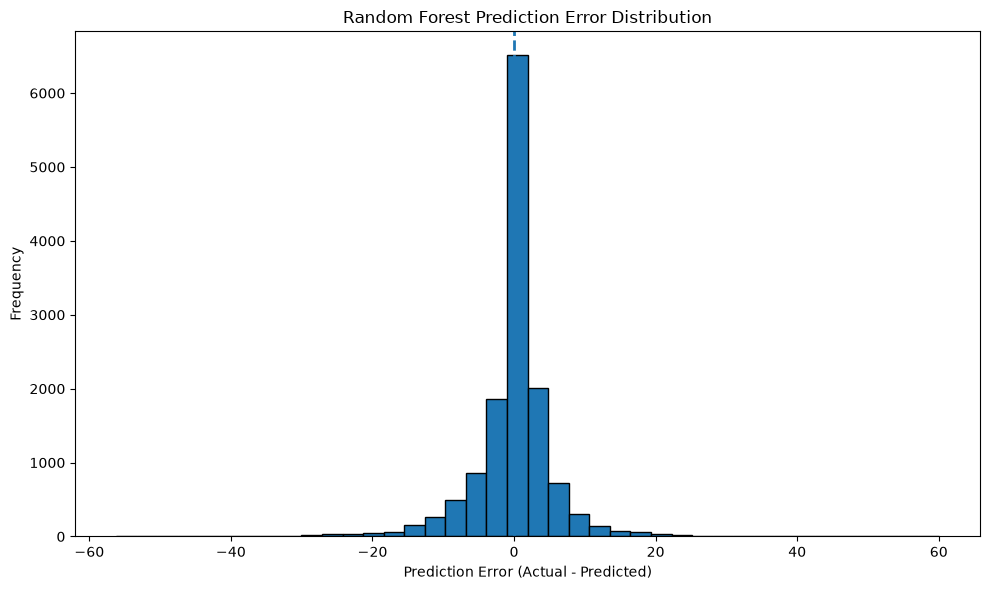

In [1635]:
plt.figure(figsize=(10, 6))

plt.hist(errors_rf, bins=40, edgecolor="black")

plt.axvline(0, linestyle="--", linewidth=2)

plt.title("Random Forest Prediction Error Distribution")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

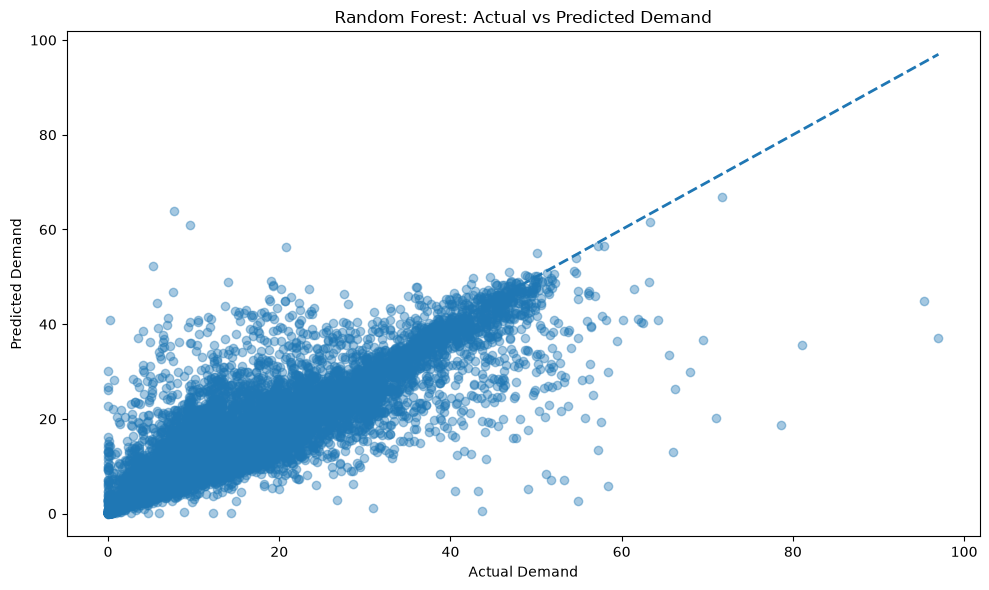

In [1636]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2
)

plt.title("Random Forest: Actual vs Predicted Demand")
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")

plt.tight_layout()
plt.show()

In [1637]:
prediction_summary = pd.DataFrame({
    "Actual Demand": y_test,
    "Predicted Demand": y_pred_rf,
    "Absolute Error": np.abs(y_test - y_pred_rf)
})

print(prediction_summary.head(10))

       Actual Demand  Predicted Demand  Absolute Error
32424          12.92         13.383337        0.463337
34002           2.67          2.639833        0.030167
56825           2.13         11.093867        8.963867
40366          39.12         35.887300        3.232700
15074           3.41          2.847873        0.562127
1918           22.30         20.568768        1.731232
25555          51.50         46.292350        5.207650
21950           6.40          5.919458        0.480542
53594          11.21         15.315800        4.105800
57467          30.29         19.596133       10.693867


In [1638]:
print("Overall Prediction Performance:")
print("Mean Absolute Error:", np.mean(np.abs(y_test - y_pred_rf)))
print("Maximum Absolute Error:", np.max(np.abs(y_test - y_pred_rf)))
print("Minimum Absolute Error:", np.min(np.abs(y_test - y_pred_rf)))

Overall Prediction Performance:
Mean Absolute Error: 3.377804692140529
Maximum Absolute Error: 60.01153333333333
Minimum Absolute Error: 3.197442310920451e-14


In [1639]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Cleaned Sessions",
        "Average Demand",
        "Median Demand",
        "Maximum Demand",
        "Average Duration",
        "Random Forest MAE",
        "Random Forest RMSE",
        "Random Forest R²"
    ],
    "Value": [
        len(df_final),
        df_final["Demand"].mean(),
        df_final["Demand"].median(),
        df_final["Demand"].max(),
        df_final["Duration"].mean(),
        mae_rf,
        rmse_rf,
        r2_rf
    ]
})

print(final_summary)

                   Metric         Value
0  Total Cleaned Sessions  68904.000000
1          Average Demand     16.077501
2           Median Demand     13.520000
3          Maximum Demand     97.000000
4        Average Duration    127.066324
5       Random Forest MAE      3.377805
6      Random Forest RMSE      5.842109
7        Random Forest R²      0.746991


In [1640]:
hour_demand_summary = df_final.groupby("StartHour")["Demand"].mean()

print("Peak Demand Hour:", hour_demand_summary.idxmax())
print("Peak Average Demand:", hour_demand_summary.max())

print("Lowest Demand Hour:", hour_demand_summary.idxmin())
print("Lowest Average Demand:", hour_demand_summary.min())

Peak Demand Hour: 23
Peak Average Demand: 24.112476572958503
Lowest Demand Hour: 10
Lowest Average Demand: 13.130141364474493


In [1641]:
charger_type_summary = df_final.groupby("ChargerType")["Demand"].agg(
    ["mean", "median", "count"]
)

print("Demand Summary by Charger Type:")
print(charger_type_summary)

Demand Summary by Charger Type:
                  mean  median  count
ChargerType                          
0            15.284283   12.40  53978
1            18.946075   17.15  14926


In [1642]:
location_high_demand = (
    df_final[df_final["DemandLevel"] == "High"]
    .groupby("Location")
    .size()
    .sort_values(ascending=False)
)

print("High Demand Sessions by Location:")
print(location_high_demand)

High Demand Sessions by Location:
Location
public area           4762
apartment             4513
resort                2808
public institution    2446
hotel                 2209
company               2207
public parking lot    1313
market                 920
camping                795
restaurant             588
sightseeing            387
golf                   328
accommodation          133
bus garage              18
dtype: int64


In [1643]:
high_demand_percentage = (
    df_final.groupby("Location")["DemandLevel"]
    .apply(lambda x: (x == "High").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

print("High Demand Percentage by Location:")
print(high_demand_percentage)

High Demand Percentage by Location:
Location
accommodation         77.78
bus garage            62.07
camping               55.25
public parking lot    39.17
public institution    36.54
apartment             35.56
public area           35.49
resort                33.56
golf                  32.73
sightseeing           32.28
market                31.89
company               30.43
restaurant            28.09
hotel                 26.58
Name: DemandLevel, dtype: float64


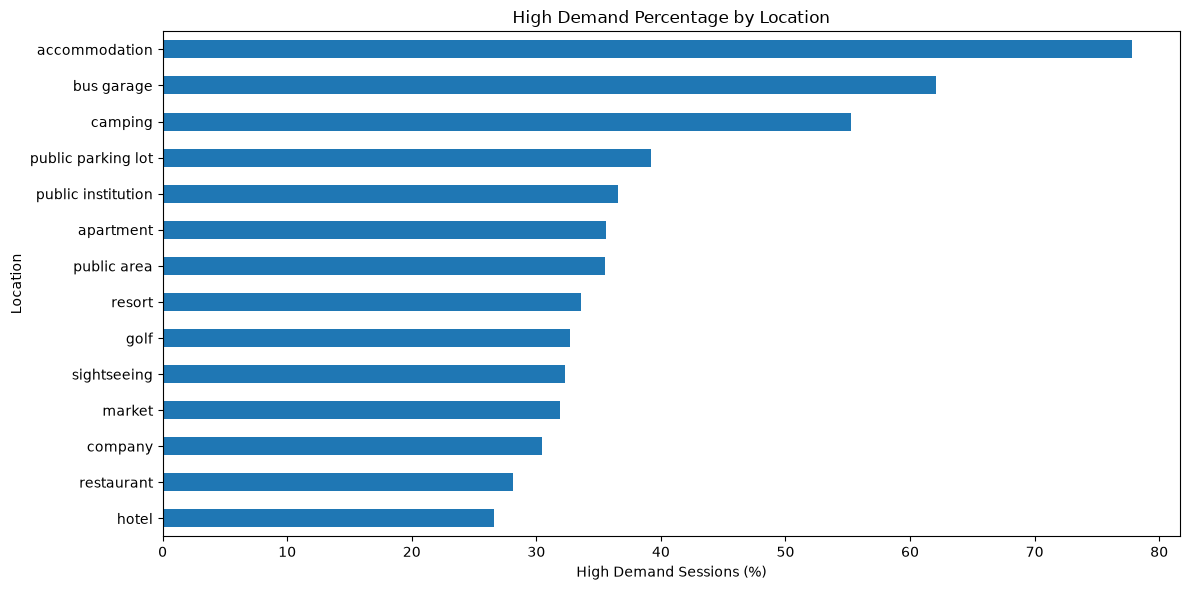

In [1644]:
plt.figure(figsize=(12, 6))

high_demand_percentage.sort_values(ascending=True).plot(
    kind="barh"
)

plt.title("High Demand Percentage by Location")
plt.xlabel("High Demand Sessions (%)")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [1645]:
print("Final Dataset Shape:", df_final.shape)
print("\nFinal Dataset Columns:")
print(df_final.columns.tolist())

Final Dataset Shape: (68904, 17)

Final Dataset Columns:
['UserID', 'ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime', 'EndDatetime', 'Duration', 'Demand', 'StartHour', 'StartDayOfWeek', 'StartMonth', 'DemandLevel']


In [1646]:
# Define target variable
y = df_final["Demand"]

# Select numerical features for prediction
X = df_final[
    ["ChargerType", "ChargerCompany", "Duration", "StartHour", "StartMonth"]
]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Features (X):
   ChargerType  ChargerCompany  Duration  StartHour  StartMonth
0            0               1       185         20           9
1            0               1        90         20           9
2            0               1        60         18           9
3            0               1       344         18           9
4            0               1       300         19           9

Target (y):
0    20.36
1    10.19
2     6.78
3    37.65
4    33.81
Name: Demand, dtype: float64

Feature Shape: (68904, 5)
Target Shape: (68904,)


In [1647]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Data Shape: (55123, 5)
Testing Data Shape: (13781, 5)
Training Target Shape: (55123,)
Testing Target Shape: (13781,)


In [1648]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [1649]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of Predictions:", len(y_pred_rf))
print("\nFirst 10 Predictions:")
print(y_pred_rf[:10])

Predictions generated successfully!
Number of Predictions: 13781

First 10 Predictions:
[13.38738667  2.63983333 11.12926667 36.05115     2.84787333 20.63346786
 46.33255     5.907375   15.2365     19.5961328 ]


In [1650]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Performance:
MAE: 3.377944096069208
RMSE: 5.842699695207711
R² Score: 0.74694003421351


In [1651]:
feature_names = [
    "ChargerType",
    "ChargerCompany",
    "Duration",
    "StartHour",
    "StartMonth"
]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
          Feature  Importance
2        Duration    0.771201
0     ChargerType    0.092876
3       StartHour    0.065678
4      StartMonth    0.056325
1  ChargerCompany    0.013920


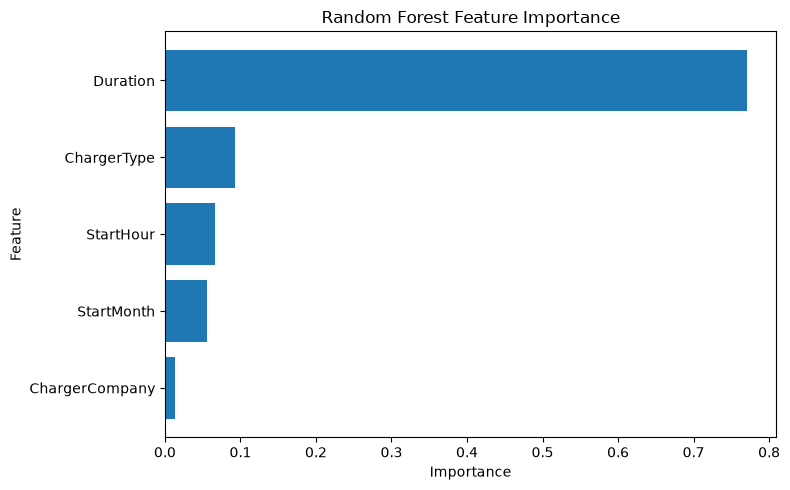

In [1652]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [1653]:
rf_summary = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score"
    ],
    "Value": [
        mae_rf,
        rmse_rf,
        r2_rf
    ]
})

print("Random Forest Model Summary:")
print(rf_summary)

Random Forest Model Summary:
                           Metric     Value
0       Mean Absolute Error (MAE)  3.377944
1  Root Mean Squared Error (RMSE)  5.842700
2                        R² Score  0.746940


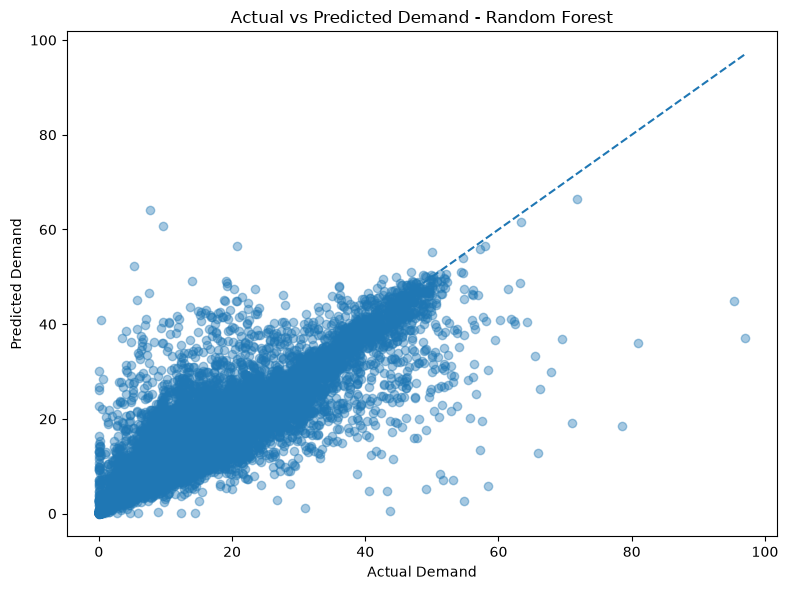

In [1654]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.4)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand - Random Forest")

min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

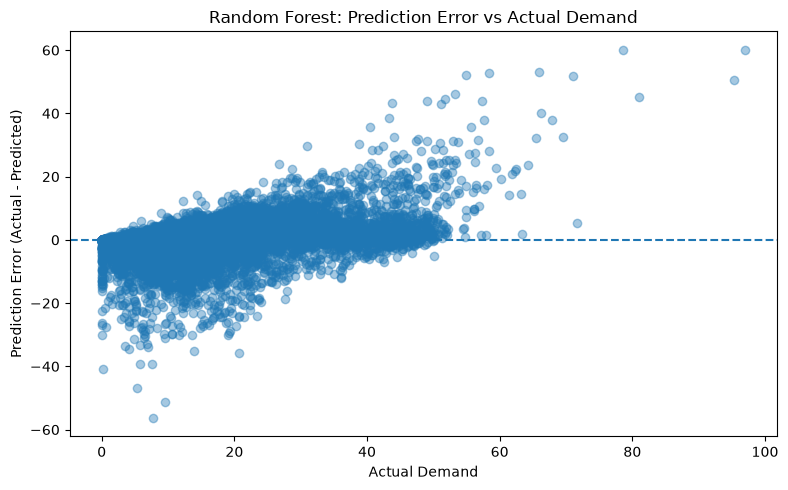

In [1655]:
plt.figure(figsize=(8, 5))

errors_rf = y_test - y_pred_rf

plt.scatter(y_test, errors_rf, alpha=0.4)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Actual Demand")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.title("Random Forest: Prediction Error vs Actual Demand")

plt.tight_layout()
plt.show()

In [1656]:
print("========== RANDOM FOREST FINAL RESULTS ==========")

print("\nModel Performance:")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

print("\nFeature Importance:")
print(feature_importance.to_string(index=False))

========== RANDOM FOREST FINAL RESULTS ==========

Model Performance:
MAE  : 3.3779
RMSE : 5.8427
R²   : 0.7469

Feature Importance:
       Feature  Importance
      Duration    0.771201
   ChargerType    0.092876
     StartHour    0.065678
    StartMonth    0.056325
ChargerCompany    0.013920


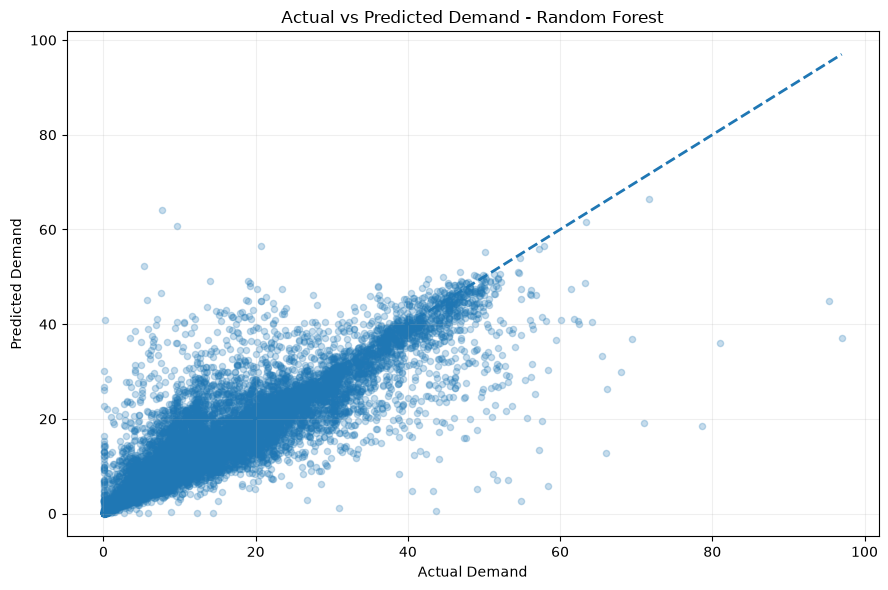

In [1657]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.25,
    s=20
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand - Random Forest")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [1658]:
residuals = y_test - y_pred_rf

print("Residual Analysis:")
print("Mean Residual:", np.mean(residuals))
print("Maximum Positive Error:", np.max(residuals))
print("Maximum Negative Error:", np.min(residuals))
print("Residual Standard Deviation:", np.std(residuals))

Residual Analysis:
Mean Residual: 0.018157560413108887
Maximum Positive Error: 60.11813333333335
Maximum Negative Error: -56.35230000000004
Residual Standard Deviation: 5.84267148069957


In [1659]:
print("========== FINAL PROJECT FINDINGS ==========")

print("\nDataset:")
print("Total cleaned sessions:", len(df_final))

print("\nDemand:")
print("Average demand:", round(df_final["Demand"].mean(), 2))
print("Median demand:", round(df_final["Demand"].median(), 2))
print("Maximum demand:", round(df_final["Demand"].max(), 2))

print("\nRandom Forest Performance:")
print("MAE:", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R² Score:", round(r2_rf, 4))

print("\nMost Important Feature:")
print(feature_importance.iloc[0]["Feature"],
      "->", round(feature_importance.iloc[0]["Importance"], 4))

print("\nPeak Demand Hour:", hour_demand_summary.idxmax())
print("Peak Average Demand:", round(hour_demand_summary.max(), 2))

print("\nLowest Demand Hour:", hour_demand_summary.idxmin())
print("Lowest Average Demand:", round(hour_demand_summary.min(), 2))

========== FINAL PROJECT FINDINGS ==========

Dataset:
Total cleaned sessions: 68904

Demand:
Average demand: 16.08
Median demand: 13.52
Maximum demand: 97.0

Random Forest Performance:
MAE: 3.3779
RMSE: 5.8427
R² Score: 0.7469

Most Important Feature:
Duration -> 0.7712

Peak Demand Hour: 23
Peak Average Demand: 24.11

Lowest Demand Hour: 10
Lowest Average Demand: 13.13


In [1660]:
ml_results = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score"
    ],
    "Random Forest": [
        mae_rf,
        rmse_rf,
        r2_rf
    ]
})

ml_results["Random Forest"] = ml_results["Random Forest"].round(4)

print("Machine Learning Model Performance:")
print(ml_results)

Machine Learning Model Performance:
                           Metric  Random Forest
0       Mean Absolute Error (MAE)         3.3779
1  Root Mean Squared Error (RMSE)         5.8427
2                        R² Score         0.7469


In [1661]:
# Save final cleaned dataset
df_final.to_csv("../data/Cleaned_ChargingRecords.csv", index=False)

# Save actual vs predicted values
prediction_results = pd.DataFrame({
    "Actual_Demand": y_test.values,
    "Predicted_Demand": y_pred_rf
})

prediction_results.to_csv("../data/RandomForest_Predictions.csv", index=False)

print("Files saved successfully!")
print("Cleaned dataset:", df_final.shape)
print("Prediction results:", prediction_results.shape)

Files saved successfully!
Cleaned dataset: (68904, 17)
Prediction results: (13781, 2)
